# 09 — SHAP Analysis & Specification Sensitivity

**Purpose:** Comprehensive SHAP interpretability analysis across specifications, investigating what each model actually relies on and leading to a change in the final model decision.

**Original model:** ST + metadata (0.765 macro F1). **Final model after SHAP audit:** ST without metadata (0.750). Changed because SHAP revealed the metadata model classifies by source type rather than content — see Sections 4-5 for the evidence and Sections 8-9 for the ablation tests that confirmed it.

**What this notebook does:**
1. **Val evaluation** — confirms ST + metadata performance (0.765 F1, 91.6% top-2) before investigation
2. **TF-IDF SHAP** (LinearExplainer) — word-level SHAP on the baseline model. Not a warm-up — this is one half of the specification comparison, showing how keyword matching treats text as evidence
3. **ST + metadata SHAP** (KernelExplainer) — reveals metadata dominates 4/6 categories. The model classifies by source type, not content
4. **Proxy concentration score** — quantifies metadata dependency: 27.6% average, two categories above 40%
5. **Text-level SHAP** (PartitionExplainer) — human-readable word attributions on the ST without metadata. Shows what the production model relies on for each prediction
6. **Individual article SHAP** — correct and misclassified examples per category. Every misclassification is a multi-label article
7. **Global text SHAP** — averaged across all articles per category. Reveals `what_matters_ed` has a coherent poverty/welfare theme invisible at the individual level
8. **Ablation: ST without metadata** — SHAP landscape shifts completely, accuracy drops only 1.5 points. Confirms metadata is a shortcut, not a dependency
9. **Ablation: metadata-only baseline** — 0.316 F1 (near random). Embeddings carry the real classification power
10. **Ablation: XGBoost** — 0.700 F1, underperforms LogReg. Small dataset + high dimensions = overfitting
11. **Waterfall plots** — embedding-level explanations for high-confidence wrong and low-confidence correct cases
12. **Normative divergence** — ST vs Claude disagree on 26% of articles. ST wins 2:1 in the disagreement zone. Claude classifies by document type, ST by topic content

**Next:** Notebook 10 — Production pipeline (ST without metadata, inference, monitoring)


# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import shap
from pathlib import Path

from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

%matplotlib inline

shap.initjs()

In [2]:
DATA_DIR = Path('../data/modelling')
MODEL_DIR = Path('../models')

# 1. Load models and val data

In [3]:
# Load trained models
tfidf_vec = joblib.load(MODEL_DIR / 'baseline_tfidf.joblib')
tfidf_clf = joblib.load(MODEL_DIR / 'baseline_logreg.joblib')
sbert_clf = joblib.load(MODEL_DIR / 'sbert_classifier.joblib')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

with open(DATA_DIR / 'metadata_columns.json') as f:
    metadata_cols = json.load(f)

# Load val data
val_df = pd.read_csv(DATA_DIR / 'val.csv')
y_val = val_df['target']
label_names = sorted(y_val.unique())

# Generate val predictions
sbert_emb_val = np.load(MODEL_DIR / 'sbert_val_embeddings.npy')
X_val_sbert = np.hstack([sbert_emb_val, val_df[metadata_cols].values])
sbert_proba_val = sbert_clf.predict_proba(X_val_sbert)
sbert_pred_val = sbert_clf.predict(X_val_sbert)
sbert_classes = sbert_clf.classes_

print(f'Val: {len(val_df)} rows')
print(f'Models loaded.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Val: 167 rows
Models loaded.


# 2. Val set evaluation — ST + metadata 

Evaluating the ST + metadata model on the val set before SHAP investigation. This is the model that scored highest in notebook 04 (0.765 macro F1). SHAP analysis in Sections 4-9 below reveals why we ultimately chose the ST without metadata (0.750) for production instead.

In [4]:
# Evaluate Sentence Transformer on val set
y_true = val_df['target']
y_pred = sbert_pred_val

macro_f1 = f1_score(y_true, y_pred, average='macro')
top1_acc = (y_pred == y_true).mean()

# Top-2
top2_correct = [
    np.where(sbert_classes == true)[0][0] in np.argsort(sbert_proba_val[i])[-2:]
    for i, true in enumerate(y_true)
]
top2_acc = np.mean(top2_correct)

print(f'Sentence Transformer + metadata — Macro F1: {macro_f1:.3f}')
print(f'Top-1 accuracy: {top1_acc:.3f}')
print(f'Top-2 accuracy: {top2_acc:.3f}')
print(f'\n{classification_report(y_true, y_pred)}')

Sentence Transformer + metadata — Macro F1: 0.765
Top-1 accuracy: 0.754
Top-2 accuracy: 0.916

                                         precision    recall  f1-score   support

                                 edtech       0.89      0.92      0.91        26
                           four_nations       0.95      0.82      0.88        22
               policy_practice_research       0.71      0.71      0.71        24
political_environment_key_organisations       0.65      0.56      0.60        36
                            teacher_rrd       0.70      0.90      0.79        29
                        what_matters_ed       0.72      0.70      0.71        30

                               accuracy                           0.75       167
                              macro avg       0.77      0.77      0.76       167
                           weighted avg       0.76      0.75      0.75       167



### Val set evaluation — ST + metadata model (under investigation)

**Macro F1: 0.765, Top-2: 91.6%** — confirmed on val set. These were the initial production numbers before SHAP analysis revealed metadata dependency (see Section 4). The final production model is ST without metadata (0.750) — see Sections 8-9 for the ablation that led to this decision.

**Strong classes (recall — the metric that matters for this use case):**
- `edtech` (recall 92%) — semantic embeddings handle the vocabulary overlap that defeated TF-IDF
- `teacher_rrd` (recall 90%) — catches most teacher articles, though precision is lower (70%) due to keyword-triggering bias
- `four_nations` (recall 82%) — distinctive geographic vocabulary

**Weaker classes (recall):**
- `what_matters_ed` (recall 70%) — in the overlapping triangle
- `policy_practice_research` (recall 71%) — balanced but struggles with the triangle
- `political_environment` (recall 56%) — the broad catch-all remains hardest

**Why recall matters:** the curator can quickly remove a wrong suggestion but can't find articles buried in the wrong category. Low recall means missing articles — that's worse than extra suggestions.


# 3. SHAP on TF-IDF + Logistic Regression

We run SHAP on both specifications (TF-IDF and Sentence Transformer) not to choose between them, but to demonstrate that the choice itself changes what the system treats as evidence. The TF-IDF analysis below is not a warm-up for the "real" model — it is one half of a specification sensitivity comparison. Comparing SHAP patterns across specifications shows *why* different models produce different outputs, not just *that* they do.

Global feature importance per class — which words drive each category?

In [5]:
X_val_tfidf = tfidf_vec.transform(val_df['text_clean'])

explainer_tfidf = shap.LinearExplainer(tfidf_clf, X_val_tfidf)
shap_values_tfidf = explainer_tfidf.shap_values(X_val_tfidf)

print(f'SHAP values shape: {len(shap_values_tfidf)} classes, {shap_values_tfidf[0].shape} per class')

SHAP values shape: 167 classes, (4453, 6) per class


In [8]:
# Per-class top SHAP features
tfidf_feature_names = tfidf_vec.get_feature_names_out()

for i, cls in enumerate(tfidf_clf.classes_):
    # shap_values_tfidf is (articles, features, classes) — slice by class
    shap_class = np.asarray(shap_values_tfidf[:, :, i])
    mean_shap = np.abs(shap_class).mean(axis=0).flatten()
    top_idx = np.argsort(mean_shap)[-10:][::-1]
    
    print(f'\n--- {cls} ---')
    for j in top_idx:
        print(f'  {mean_shap[j]:.4f}  {tfidf_feature_names[j]}')



--- edtech ---
  0.0416  edtech
  0.0360  education
  0.0290  school
  0.0263  use
  0.0257  children
  0.0227  impact
  0.0223  england
  0.0222  digital
  0.0208  child
  0.0204  teacher

--- four_nations ---
  0.0581  scottish
  0.0521  wales
  0.0475  education
  0.0403  learning
  0.0387  child
  0.0377  government
  0.0366  schools
  0.0336  scottish government
  0.0300  poverty
  0.0272  welsh

--- policy_practice_research ---
  0.1097  research
  0.0693  policy
  0.0531  schools
  0.0448  teachers
  0.0426  children
  0.0313  teacher
  0.0294  school
  0.0214  university
  0.0205  evidence
  0.0189  dfe

--- political_environment_key_organisations ---
  0.0444  teachers
  0.0373  ofsted
  0.0349  teacher
  0.0299  schools
  0.0272  research
  0.0188  curriculum
  0.0184  learning
  0.0184  send
  0.0166  schoolsweek
  0.0152  education

--- teacher_rrd ---
  0.1372  teacher
  0.1354  teachers
  0.0513  children
  0.0423  retention
  0.0388  teaching
  0.0379  education
  0.036

### TF-IDF SHAP results

**Per-category patterns:**

| Category | Top signal | SHAP dominance | Assessment |
|---|---|---|---|
| `teacher_rrd` | "teacher"/"teachers" (0.137, 0.135) | Two words dominate entire top 10 | **Keyword-triggering bias** — fires on "teacher" regardless of context |
| `policy_practice_research` | "research" (0.110) | 2x the next feature | **Single-keyword dependence** — mirrors Claude's over-prediction |
| `four_nations` | "scottish"/"wales"/"welsh" (0.058, 0.052, 0.027) | Geographic terms dominate | **Construct-valid** — category IS about devolved policy |
| `political_environment` | "ofsted"/"schoolsweek" (0.037, 0.017) | Source names in top 10 | **Proxy contamination** — classifying by publisher, not content |
| `edtech` | "edtech"/"digital" (0.042, 0.022) | 2 distinctive terms, 8 generic | **Keyword-dependent** — misses articles that don't use exact terms (42% recall) |
| `what_matters_ed` | "children" (0.083) | No distinctive vocabulary | **Diffuse** — hardest to classify, no strong keyword signature |

**If TF-IDF were the final model, you'd address this with:**
- N-gram emphasis — weight bigrams ("teacher recruitment") over unigrams ("teacher") to reduce false positives
- Source name removal — strip "schoolsweek", "ofsted" etc. from text to force content-based classification
- Domain vocabulary features — curated word lists per category as additional binary features

**Why these aren't needed:** the Sentence Transformer already handles keyword-triggering through contextual embeddings ("teacher recruitment" and "teacher said" produce different vectors) and vocabulary gaps through semantic similarity (captures edtech concepts without needing the exact word). This is the specification sensitivity argument made practical — feature engineering that would help TF-IDF is unnecessary for the ST because the embedding already encodes what the engineering would add.


# 4. SHAP on Sentence Transformer + metadata (investigating metadata dependency)

This section investigates what the ST + metadata model actually relies on in terms of SHAP attribution. The KernelExplainer reveals that metadata features dominate 4/6 categories — the classifier preferentially uses source type over semantic content when both are available. This finding led to the decision to use **ST without metadata (0.750) for production** instead of ST + metadata (0.765). Bootstrap confidence intervals confirm the difference is not statistically significant (CIs overlap: 0.696–0.823 vs 0.678–0.812). See Sections 8-9 for the ablation tests.

The analysis also serves as the second half of the specification comparison: where Section 3 showed TF-IDF treating each word as a context-free token, the text-level SHAP in Section 6 shows the Sentence Transformer weighting the *same words* differently depending on surrounding context. Same data, same task, different attribution patterns — specification sensitivity at the feature level.

**KernelExplainer** (embedding-level): explains which of the 384 embedding dimensions + 17 metadata features matter most for the ST + metadata model. Embedding dimensions aren't human-readable ("emb_42" doesn't map to a word), but the analysis reveals how much of each category's decision comes from metadata shortcuts vs semantic content. This is the analysis that revealed the metadata dependency and changed the final model decision. Followed by proxy concentration scoring in Section 5.

In [13]:
# KernelExplainer on full val set (167 articles)
X_sample = X_val_sbert
sample_idx = np.arange(len(X_val_sbert))

# Background data for KernelExplainer
background = shap.kmeans(X_val_sbert, 10)

print('Running KernelExplainer on 167 val articles...')
explainer_sbert = shap.KernelExplainer(sbert_clf.predict_proba, background)
shap_values_sbert = explainer_sbert.shap_values(X_sample, nsamples=200)

print(f'Done. SHAP values shape: {len(shap_values_sbert)} classes')

Running KernelExplainer on 167 val articles...


  0%|          | 0/167 [00:00<?, ?it/s]

Done. SHAP values shape: 167 classes


In [16]:
# Feature names: embedding dimensions + metadata columns
feature_names_sbert = [f'emb_{i}' for i in range(384)] + metadata_cols

# Which features matter most overall?
for i, cls in enumerate(label_names):
    mean_shap = np.abs(shap_values_sbert[:, :, i]).mean(axis=0)
    top_idx = np.argsort(mean_shap)[-10:][::-1]
    
    print(f'\n--- {cls} ---')
    n_meta = 0
    for j in top_idx:
        name = feature_names_sbert[j]
        is_meta = '[metadata]' if name in metadata_cols else ''
        if is_meta:
            n_meta += 1
        print(f'  {mean_shap[j]:.4f}  {name} {is_meta}')
    print(f'  -> {n_meta}/10 top features are metadata')



--- edtech ---
  0.0033  emb_291 
  0.0032  emb_158 
  0.0030  item_academic_article [metadata]
  0.0028  emb_278 
  0.0027  org_knowledge_mobiliser_think_tank_sector [metadata]
  0.0024  item_news_article [metadata]
  0.0021  emb_222 
  0.0020  org_academic_sector [metadata]
  0.0020  emb_54 
  0.0016  emb_23 
  -> 4/10 top features are metadata

--- four_nations ---
  0.0376  org_government_public_sector [metadata]
  0.0085  item_report [metadata]
  0.0044  org_research_evidence_sector [metadata]
  0.0036  org_academic_sector [metadata]
  0.0035  item_government_document [metadata]
  0.0028  item_blog_post [metadata]
  0.0017  emb_292 
  0.0016  emb_192 
  0.0015  emb_71 
  0.0015  emb_242 
  -> 6/10 top features are metadata

--- policy_practice_research ---
  0.0217  org_academic_sector [metadata]
  0.0166  org_media_sector [metadata]
  0.0114  item_government_document [metadata]
  0.0052  org_government_public_sector [metadata]
  0.0046  item_news_article [metadata]
  0.0034  org

### ST SHAP results — metadata dependency (KernelExplainer, 167 articles)

| Category | Metadata in top 10 | Top feature | SHAP value | What it means |
|---|---|---|---|---|
| `policy_practice_research` | **10/10** | org_academic_sector | 0.022 | Entirely classified by source/document type — no embedding in top 10 |
| `political_environment` | **9/10** | org_academic_sector | 0.007 | Distinguished from policy_practice by metadata *combination*, not content |
| `what_matters_ed` | **9/10** | org_government_public_sector | 0.020 | "government or media + news article" = this category |
| `four_nations` | **6/10** | org_government_public_sector | 0.038 | Devolved government sources dominate — strongest single SHAP value |
| `teacher_rrd` | **5/10** | item_news_article | 0.015 | Teacher stories come from news; emb_97 is strongest embedding signal |
| `edtech` | **4/10** | emb_291 | 0.003 | Most balanced — embeddings contribute meaningfully alongside metadata |

**Key finding:** LogReg prefers metadata because it's cleaner signal — 17 binary columns vs 384 continuous embedding dimensions. But metadata alone scores 0.316 (near random). The embeddings carry the real classification power (0.750 without metadata); metadata is a convenient shortcut the classifier exploits, not the source of predictive ability.

**SST implication:** adding metadata is a specification choice that barely changes accuracy (+1.5 points) but completely changes *what the model treats as evidence*. This is specification sensitivity that accuracy alone cannot detect.


# 5. Proxy concentration score — ST + metadata model

What percentage of each category's SHAP importance comes from metadata features (proxies) vs embedding dimensions (semantic content)? This quantifies the metadata dependency found in the KernelExplainer analysis above. These scores are the reason we chose to remove metadata for the production model.

In [55]:
# Proxy features = metadata columns (organisation type, item type)
PROXY_INDICES = [i for i, name in enumerate(feature_names_sbert) if name in metadata_cols]
CONTENT_INDICES = [i for i in range(384)]  # embedding dimensions

print(f"{'Category':<45} {'Proxy %':>10} {'Content %':>12} {'Assessment'}")
print(f"{'-'*85}")

proxy_scores = {}
for i, cls in enumerate(label_names):
    total_shap = np.abs(shap_values_sbert[:, :, i]).sum(axis=1).mean()
    proxy_shap = np.abs(shap_values_sbert[:, PROXY_INDICES, i]).sum(axis=1).mean()
    content_shap = np.abs(shap_values_sbert[:, CONTENT_INDICES, i]).sum(axis=1).mean()
    
    proxy_pct = proxy_shap / total_shap
    content_pct = content_shap / total_shap
    proxy_scores[cls] = proxy_pct
    
    assessment = 'HIGH proxy' if proxy_pct > 0.40 else 'moderate' if proxy_pct > 0.20 else 'low proxy'
    print(f'{cls:<45} {proxy_pct:>9.1%} {content_pct:>11.1%} {assessment}')

print(f'\nAverage proxy concentration: {np.mean(list(proxy_scores.values())):.1%}')


Category                                         Proxy %    Content % Assessment
-------------------------------------------------------------------------------------
edtech                                            11.3%       88.7% low proxy
four_nations                                      33.3%       66.7% moderate
policy_practice_research                          42.4%       57.6% HIGH proxy
political_environment_key_organisations           20.3%       79.7% moderate
teacher_rrd                                       16.5%       83.5% low proxy
what_matters_ed                                   41.6%       58.4% HIGH proxy

Average proxy concentration: 27.6%


In [67]:
# Bootstrap proxy concentration
boot_proxy = []
for _ in range(1000):
    idx = resample(np.arange(shap_values_sbert.shape[0]), random_state=None)
    total = np.abs(shap_values_sbert[idx]).sum(axis=(0,1)).mean()
    proxy = np.abs(shap_values_sbert[idx][:, :, :][:, PROXY_INDICES, :]).sum(axis=(0,1)).mean()
    boot_proxy.append(proxy / total)

print(f'Proxy concentration: {np.mean(boot_proxy):.1%} (95% CI: {np.percentile(boot_proxy, 2.5):.1%}–{np.percentile(boot_proxy, 97.5):.1%})')


Proxy concentration: 27.8% (95% CI: 25.9%–29.7%)


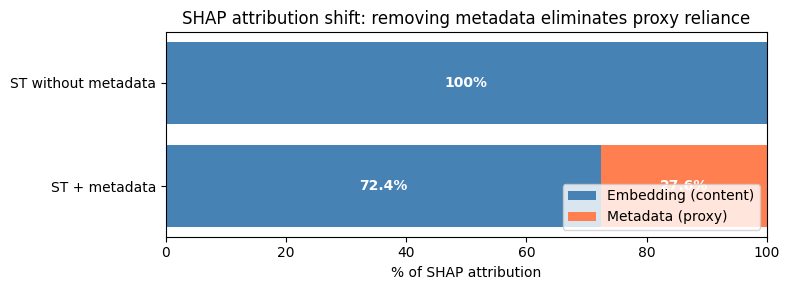

In [66]:
# Attribution shift: metadata vs embeddings
import matplotlib.pyplot as plt

categories = ['ST + metadata', 'ST without metadata']
metadata_pct = [27.6, 0]
embedding_pct = [72.4, 100]

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(categories, embedding_pct, color='steelblue', label='Embedding (content)')
ax.barh(categories, metadata_pct, left=embedding_pct, color='coral', label='Metadata (proxy)')
ax.set_xlabel('% of SHAP attribution')
ax.set_title('SHAP attribution shift: removing metadata eliminates proxy reliance')
ax.legend(loc='lower right')
for i, (e, m) in enumerate(zip(embedding_pct, metadata_pct)):
    ax.text(e/2, i, f'{e}%', ha='center', va='center', fontweight='bold', color='white')
    if m > 0:
        ax.text(e + m/2, i, f'{m}%', ha='center', va='center', fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('../outputs/shap_plots/attribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()


### Proxy concentration results

| Category | Proxy % | Content % | Assessment |
|---|---|---|---|
| `edtech` | 11.3% | 88.7% | Low proxy — embeddings drive classification |
| `four_nations` | 33.3% | 66.7% | Moderate — government source metadata contributes a third |
| `policy_practice_research` | **42.4%** | 57.6% | **HIGH** — nearly half the decision comes from "who published it" |
| `political_environment` | 20.3% | 79.7% | Moderate |
| `teacher_rrd` | 16.5% | 83.5% | Low proxy — genuine teacher content signal |
| `what_matters_ed` | **41.6%** | 58.4% | **HIGH** — metadata compensating for weak content signal |

**Average proxy concentration: 27.6%** (95% CI: 25.9%–29.7%) — more than a quarter of the model's decision-making comes from metadata across all categories. The narrow confidence interval confirms this is a stable finding, not sampling noise.

**Key findings:**
- **`policy_practice_research` (42.4% proxy)** — the same category that was 10/10 metadata in the top features. Nearly half its classification comes from source type, not content. This is the most fragile category — it would degrade most if source-topic correlations shift.
- **`what_matters_ed` (41.6% proxy)** — metadata fills the gap where content signal is weak. The global text SHAP later shows this category DOES have a poverty/welfare theme, but the model prefers the metadata shortcut when available.
- **`edtech` (11.3% proxy)** — most content-driven. The embedding captures technology concepts well enough that metadata barely matters. Consistent with its strong recall (92%).
- **`teacher_rrd` (16.5% proxy)** — also content-driven. "teacher" is such a strong semantic signal that metadata adds little.

**This is the quantitative justification for removing metadata.** Two categories have >40% proxy concentration — meaning the model classifies them more by publisher than by content. Removing metadata forces the model to use the 0.750 content-based signal for all categories, eliminating the proxy shortcuts.

# *Investigation summary so far*

The KernelExplainer and proxy concentration analysis show the ST + metadata model relies on metadata for 27.6% of its decisions, with two categories above 40%. The next sections investigate: does the model need this metadata (ablation tests), and what does it actually do with the text (PartitionExplainer)?

# 6. Text-level SHAP — ST without metadata (PartitionExplainer)

Wraps the full ST pipeline (raw text → SentenceTransformer → LogReg, metadata held at zero) so SHAP can perturb individual words and show which words drove each prediction. This is effectively the production model's behaviour — classification by content only, no metadata shortcuts. Run on all 167 val articles. Results cached to `models/shap_values_text.pkl` to avoid recomputation.

In [32]:
# Text-level SHAP: wrap full ST pipeline
def st_text_predict(texts):
    """Full pipeline: raw text -> sentence embedding -> class probabilities."""
    embeddings = sbert_model.encode(list(texts), show_progress_bar=False)
    meta = np.zeros((len(texts), len(metadata_cols)))
    X = np.hstack([embeddings, meta])
    return sbert_clf.predict_proba(X)

# Explain all val articles
sample_texts = val_df['text_clean'].tolist()
sample_labels = y_val.values

print('Running PartitionExplainer on 167 val articles...')
masker = shap.maskers.Text(tokenizer=r'\W+')
explainer_text = shap.Explainer(st_text_predict, masker=masker, output_names=label_names)
shap_values_text = explainer_text(sample_texts)
print('Done.')

# Save so you never have to rerun this
import pickle
with open(MODEL_DIR / 'shap_values_text.pkl', 'wb') as f:
    pickle.dump(shap_values_text, f)
print('Saved to models/shap_values_text.pkl')


Running PartitionExplainer on 167 val articles...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   4%|▌            | 7/167 [00:25<08:35,  3.22s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   8%|█           | 14/167 [00:54<10:22,  4.07s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  13%|█▌          | 22/167 [01:23<08:18,  3.44s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██▎         | 33/167 [02:08<08:47,  3.93s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  21%|██▌         | 35/167 [02:17<09:05,  4.13s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  23%|██▊         | 39/167 [02:33<07:59,  3.75s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  26%|███         | 43/167 [02:48<07:41,  3.72s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  29%|███▍        | 48/167 [03:08<06:49,  3.44s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  29%|███▌        | 49/167 [03:14<08:10,  4.16s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███▌        | 50/167 [03:19<08:55,  4.58s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  36%|████▎       | 60/167 [03:57<06:11,  3.47s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  37%|████▍       | 62/167 [04:08<07:51,  4.49s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  38%|████▌       | 64/167 [04:18<07:42,  4.49s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  40%|████▋       | 66/167 [04:24<06:05,  3.62s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  46%|█████▍      | 76/167 [05:07<06:16,  4.14s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  46%|█████▌      | 77/167 [05:13<06:42,  4.47s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  47%|█████▋      | 79/167 [05:23<06:49,  4.65s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  48%|█████▋      | 80/167 [05:28<06:56,  4.78s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  49%|█████▉      | 82/167 [05:38<06:51,  4.84s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████▉      | 83/167 [05:45<07:42,  5.51s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  51%|██████▏     | 86/167 [06:01<07:00,  5.19s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  52%|██████▎     | 87/167 [06:06<06:58,  5.23s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  54%|██████▍     | 90/167 [06:20<06:05,  4.75s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  55%|██████▌     | 92/167 [06:29<05:11,  4.15s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  59%|███████     | 98/167 [06:53<04:03,  3.52s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  62%|██████▊    | 103/167 [07:14<03:55,  3.68s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  63%|██████▉    | 105/167 [07:22<03:51,  3.74s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  63%|██████▉    | 106/167 [07:28<04:23,  4.32s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  66%|███████▎   | 111/167 [07:49<03:47,  4.06s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  67%|███████▍   | 112/167 [07:55<04:13,  4.60s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  68%|███████▍   | 113/167 [08:02<04:47,  5.32s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  72%|███████▉   | 121/167 [08:38<03:24,  4.44s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  76%|████████▎  | 127/167 [09:01<02:11,  3.30s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  79%|████████▋  | 132/167 [09:22<02:17,  3.93s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  81%|████████▉  | 135/167 [09:37<02:20,  4.40s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  81%|████████▉  | 136/167 [09:42<02:23,  4.62s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  83%|█████████  | 138/167 [09:52<02:19,  4.81s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  83%|█████████▏ | 139/167 [09:59<02:36,  5.58s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  84%|█████████▏ | 140/167 [10:05<02:29,  5.55s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  88%|█████████▋ | 147/167 [10:33<01:13,  3.68s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  95%|██████████▍| 158/167 [11:15<00:34,  3.85s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  95%|██████████▍| 159/167 [11:23<00:40,  5.01s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 168it [11:57,  4.32s/it]                          

Done.


In [56]:
# Load cached text-level SHAP values (skip recomputation)
import pickle
with open(MODEL_DIR / 'shap_values_text.pkl', 'rb') as f:
    shap_values_text = pickle.load(f)

sample_texts = val_df['text_clean'].tolist()
sample_labels = y_val.values

print(f'Loaded text SHAP from cache. {len(sample_texts)} articles.')


FileNotFoundError: [Errno 2] No such file or directory: '../models/shap_values_text.pkl'


--- political_environment_key_organisations: true=political_environment_key_organisations, predicted=political_environment_key_organisations (0.63) ---
Text preview: LGIU - Sticking with the mission: no time for the UK government to lose momentum The UK Labour government put mission-driven government at the heart o...


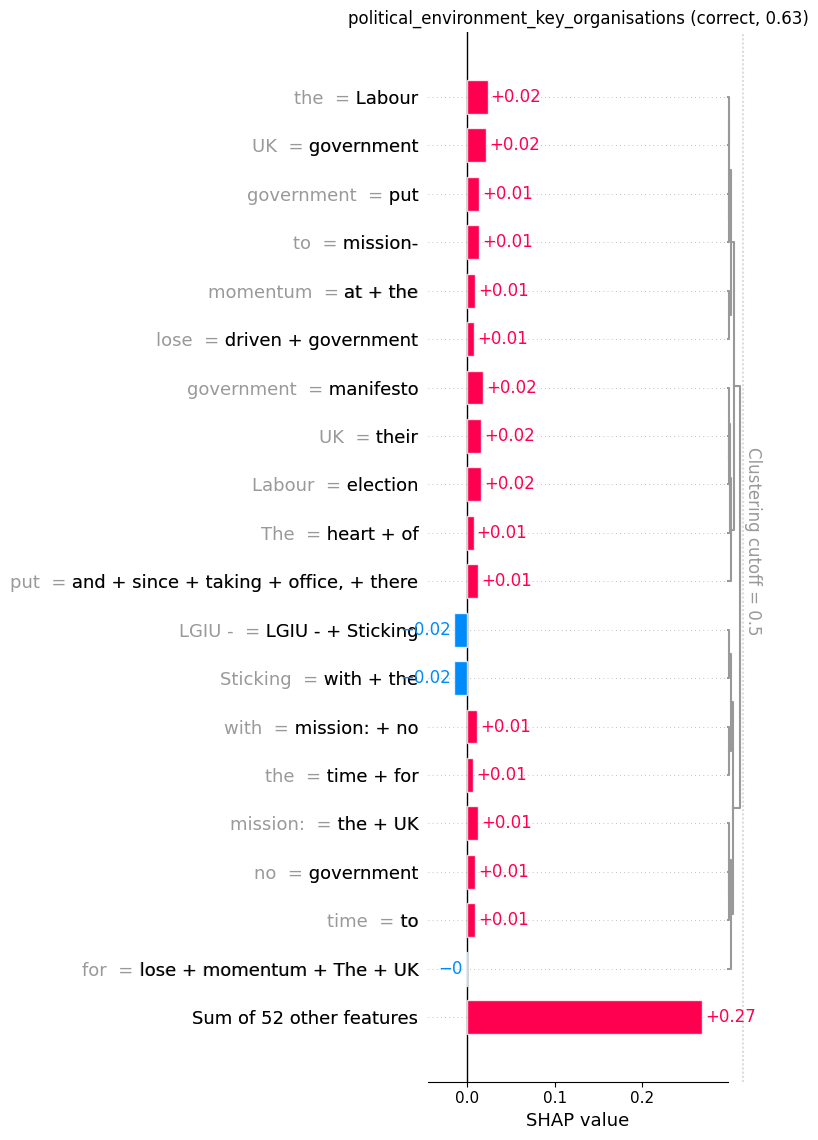


--- teacher_rrd: true=teacher_rrd, predicted=teacher_rrd (0.93) ---
Text preview: NFER - The impact of training bursaries on teacher recruitment and retention: An evaluation of impact and value for money by Dawson McLean, Sarah Tang...


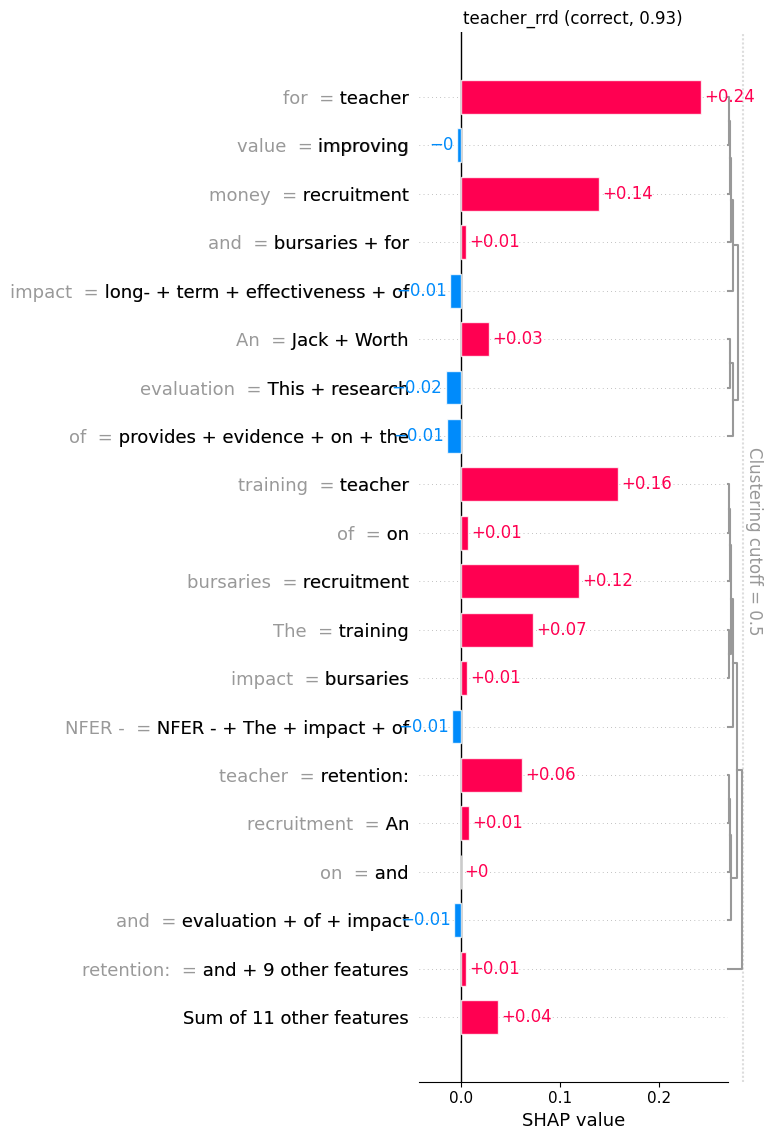


--- what_matters_ed: true=what_matters_ed, predicted=what_matters_ed (0.45) ---
Text preview: The Conversation - Home education: why are so many parents choosing it over mainstream school? Lucie Wheeler, Education Research Assistant and PhD Can...


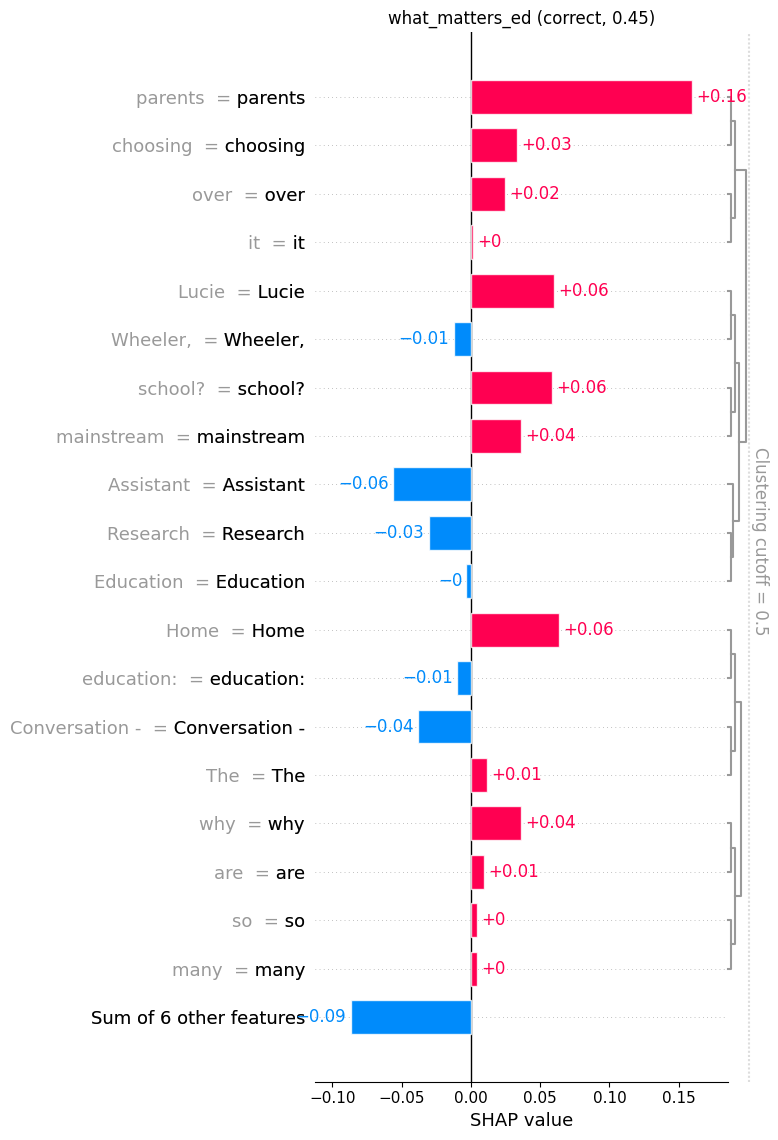


--- four_nations: true=four_nations, predicted=four_nations (0.56) ---
Text preview: Welsh Government - New programme of support announced for additional learning needs The new package of support includes a parent toolkit, greater fund...


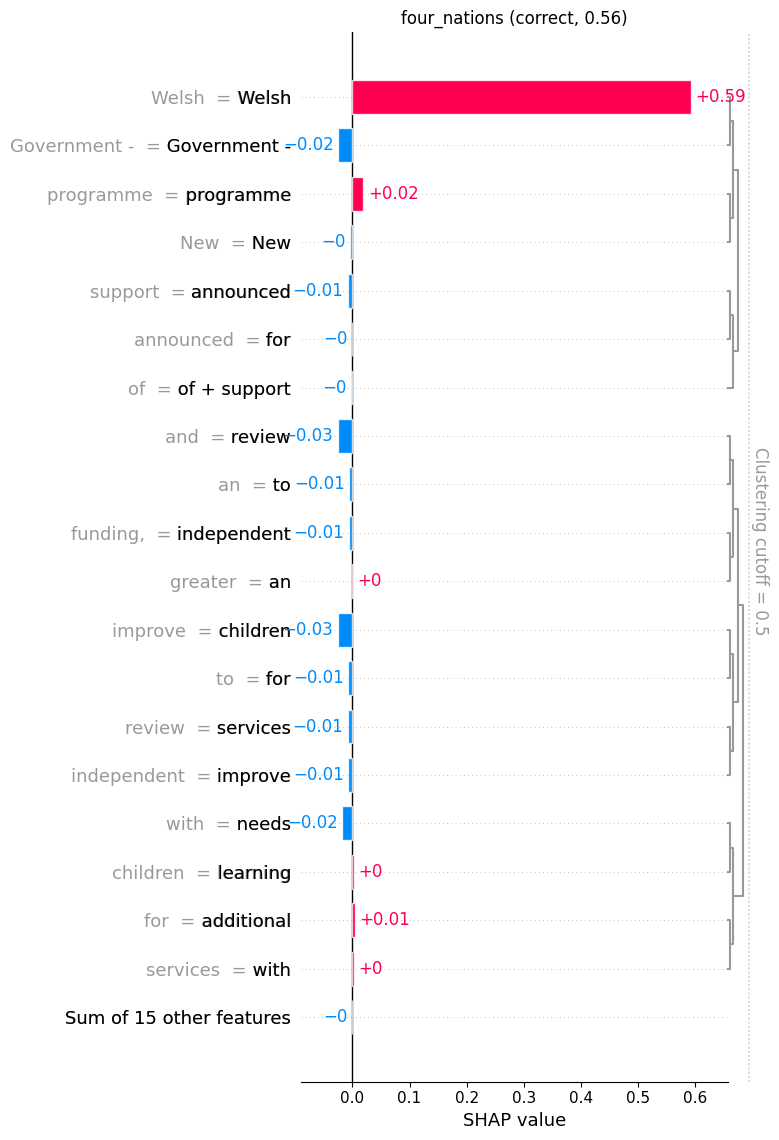


--- policy_practice_research: true=policy_practice_research, predicted=policy_practice_research (0.41) ---
Text preview: Education Endowment Foundation - New local partnerships launched to help disadvantaged pupils Up to 223 schools will benefit from eight new local part...


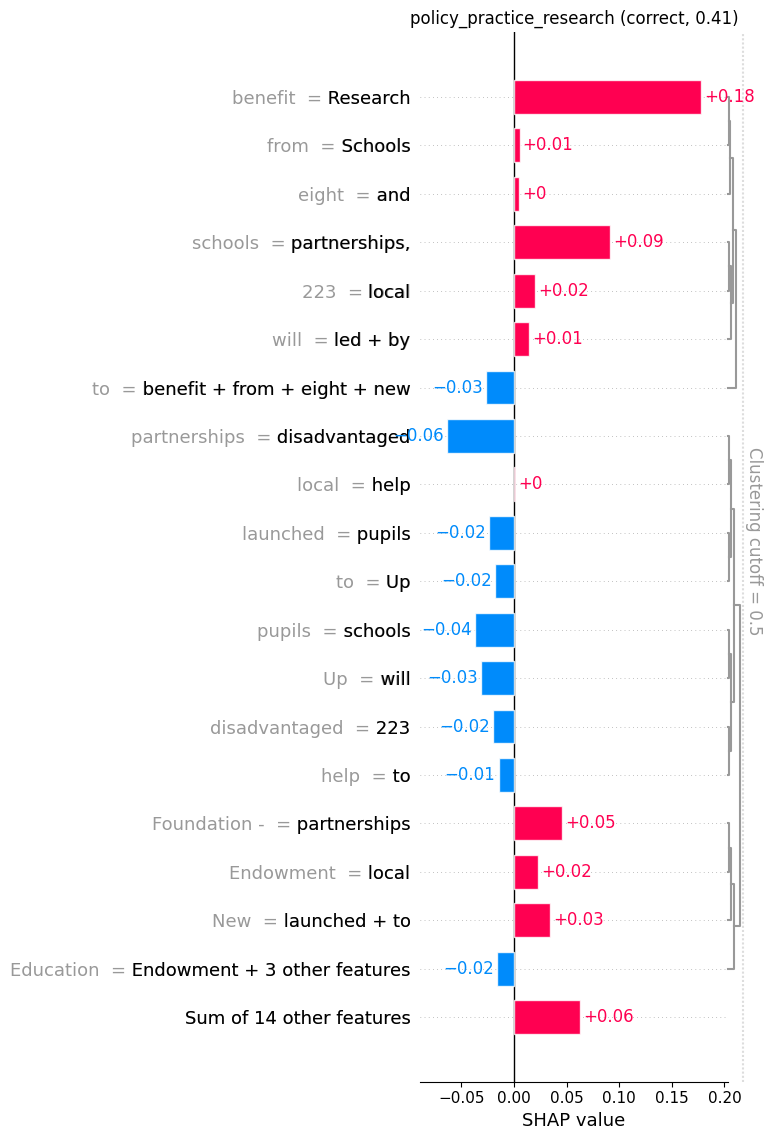


--- edtech: true=edtech, predicted=edtech (0.89) ---
Text preview: DfE - AI revolution to give teachers more time with pupils": New AI guidance , developed by the Chiltern Learning Trust and CCoT, on how to use AI saf...


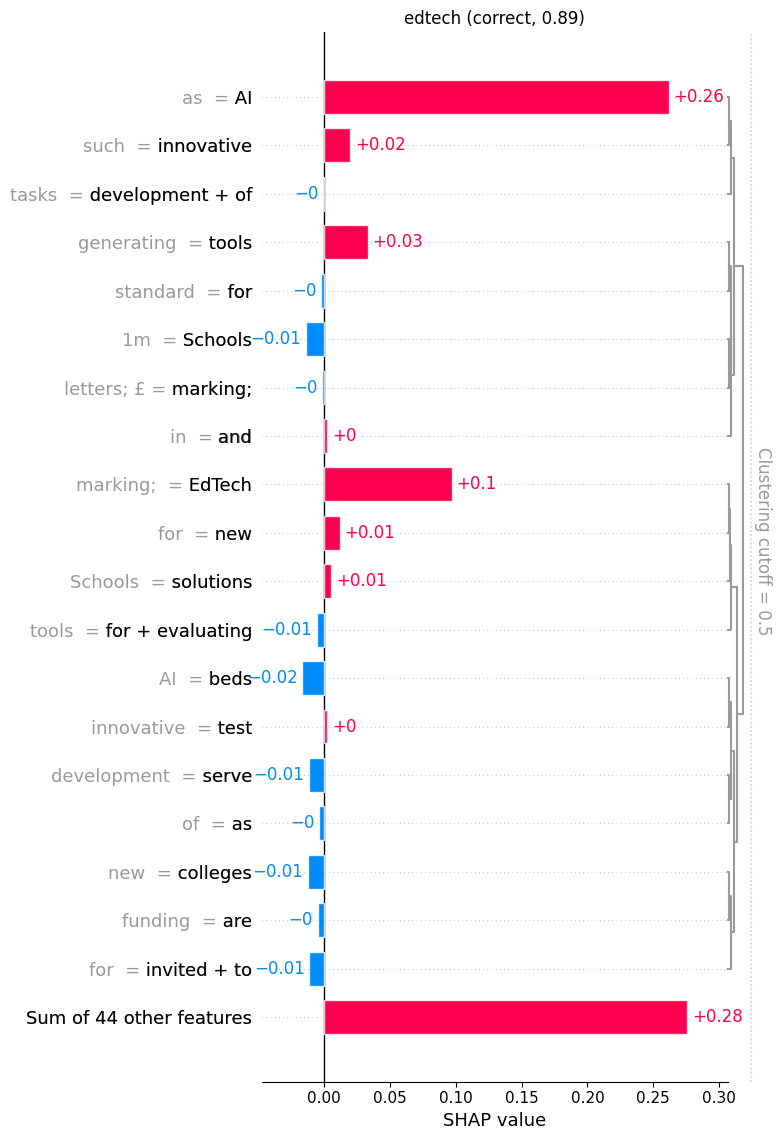

Saved 6 plots to outputs/shap_plots/


In [43]:
import os
os.makedirs('../outputs/shap_plots', exist_ok=True)

# Text-level SHAP — one correct example per category (bar plot, readable)
shown = set()
for idx in range(len(sample_texts)):
    pred_probs = st_text_predict([sample_texts[idx]])[0]
    pred_class = label_names[np.argmax(pred_probs)]
    true_label = sample_labels[idx]
    if pred_class in shown or pred_class != true_label:
        continue
    shown.add(pred_class)
    pred_class_idx = label_names.index(pred_class)
    
    print(f'\n--- {pred_class}: true={true_label}, predicted={pred_class} ({pred_probs[pred_class_idx]:.2f}) ---')
    print(f'Text preview: {sample_texts[idx][:150]}...')
    shap.plots.bar(shap_values_text[idx, :, pred_class_idx], max_display=20, show=False)
    plt.title(f'{pred_class} (correct, {pred_probs[pred_class_idx]:.2f})')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_plots/text_shap_{pred_class}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    if len(shown) == 6:
        break

print(f'Saved {len(shown)} plots to outputs/shap_plots/')



=== MISCLASSIFIED ARTICLES ===

--- true=political_environment_key_organisations, predicted=what_matters_ed (0.31) ---
Text preview: APPG for Education report– Inquiry into 'The Loss of the Love of Learning' The All-Party Parliamentary Group for Education report highlights "a number...


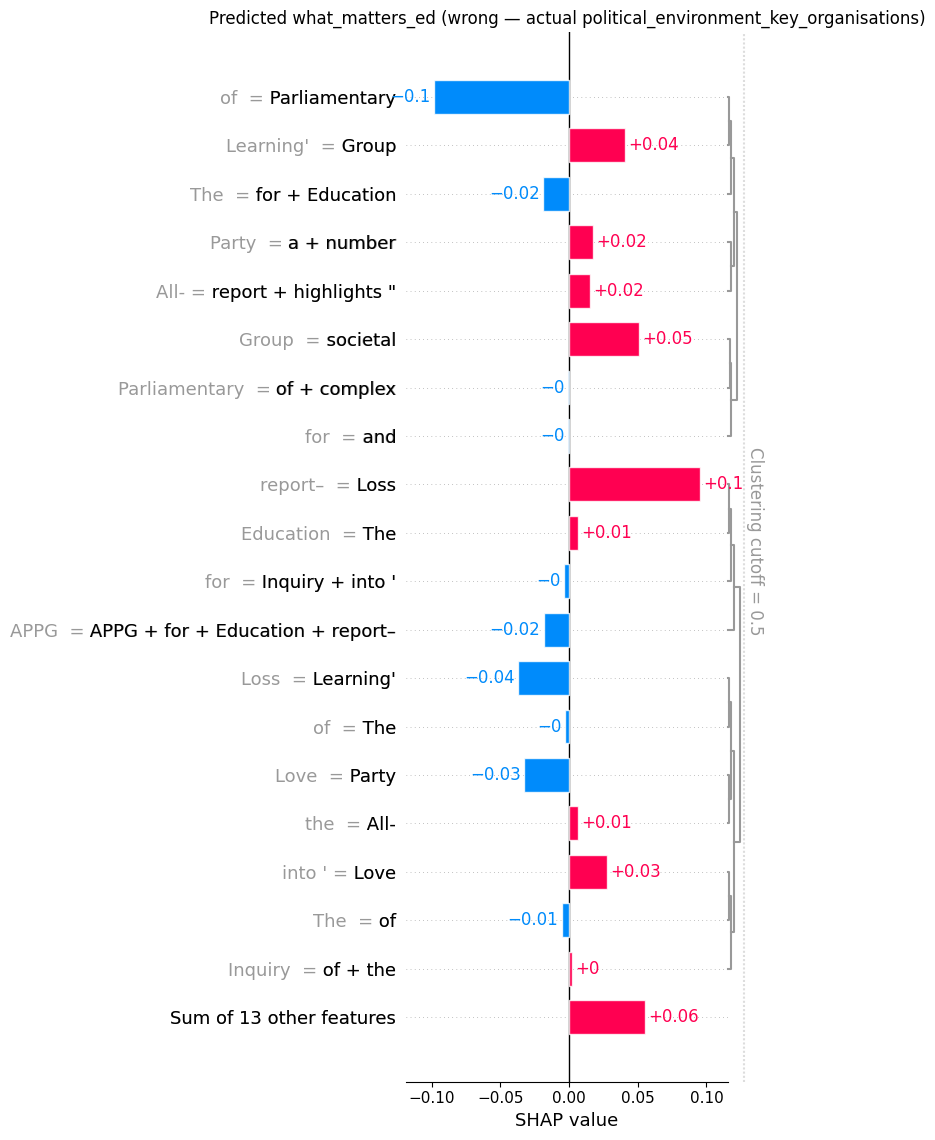


--- true=teacher_rrd, predicted=political_environment_key_organisations (0.39) ---
Text preview: Ofsted: what scrapping single-word inspection grades will mean for teachers Rachel Harding, Research Fellow in Social Sciences, Nottingham Trent Unive...


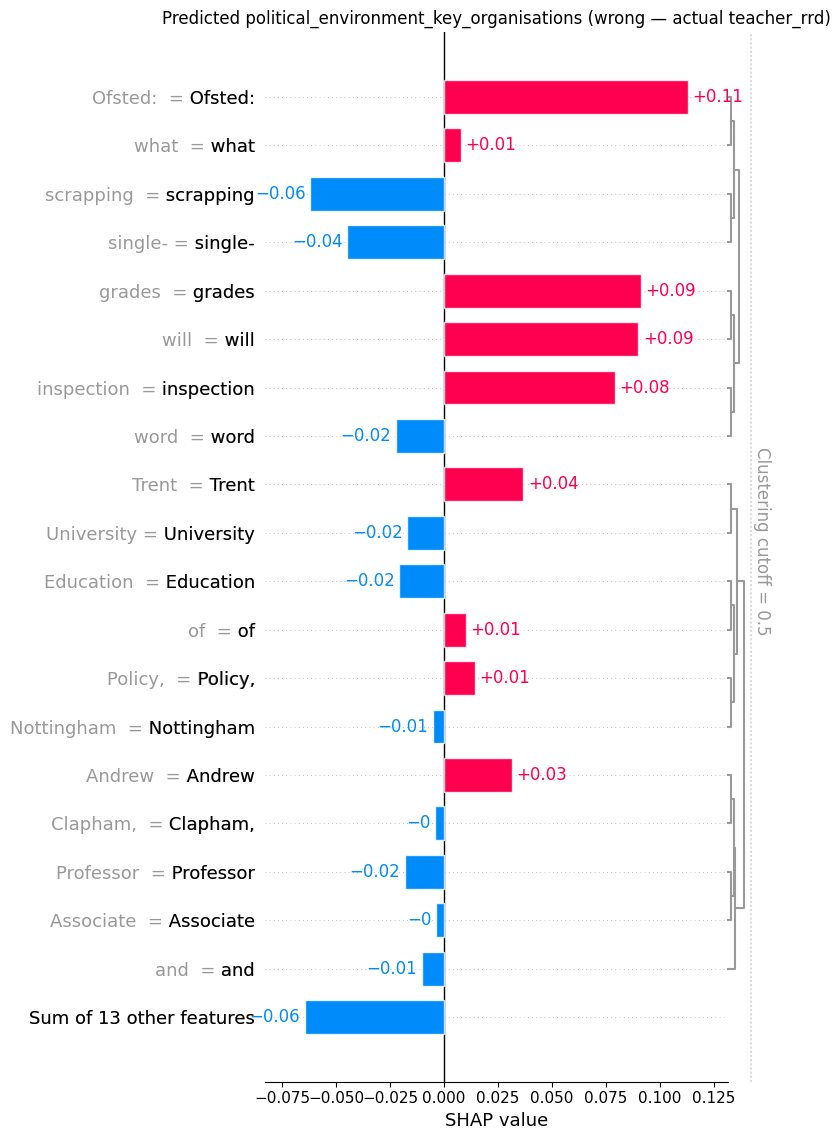


--- true=four_nations, predicted=policy_practice_research (0.45) ---
Text preview: Government devolution bill - 'Devolution Revolution' forges ahead with more powers for Mayors Raft of new powers will enable Mayors to drive economic ...


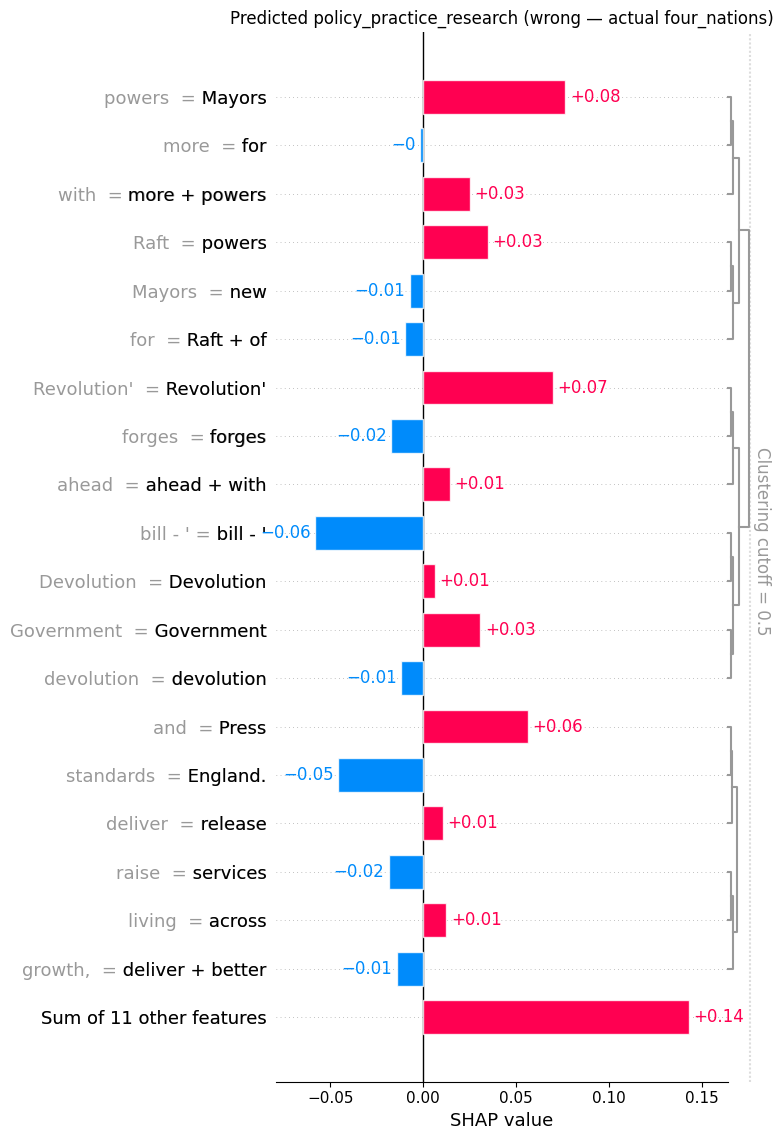


--- true=what_matters_ed, predicted=political_environment_key_organisations (0.39) ---
Text preview: The Conversation - Too many students drop out of A-levels – here's how to help them pick a course they'll stick with Nigel Newton discusses his recent...


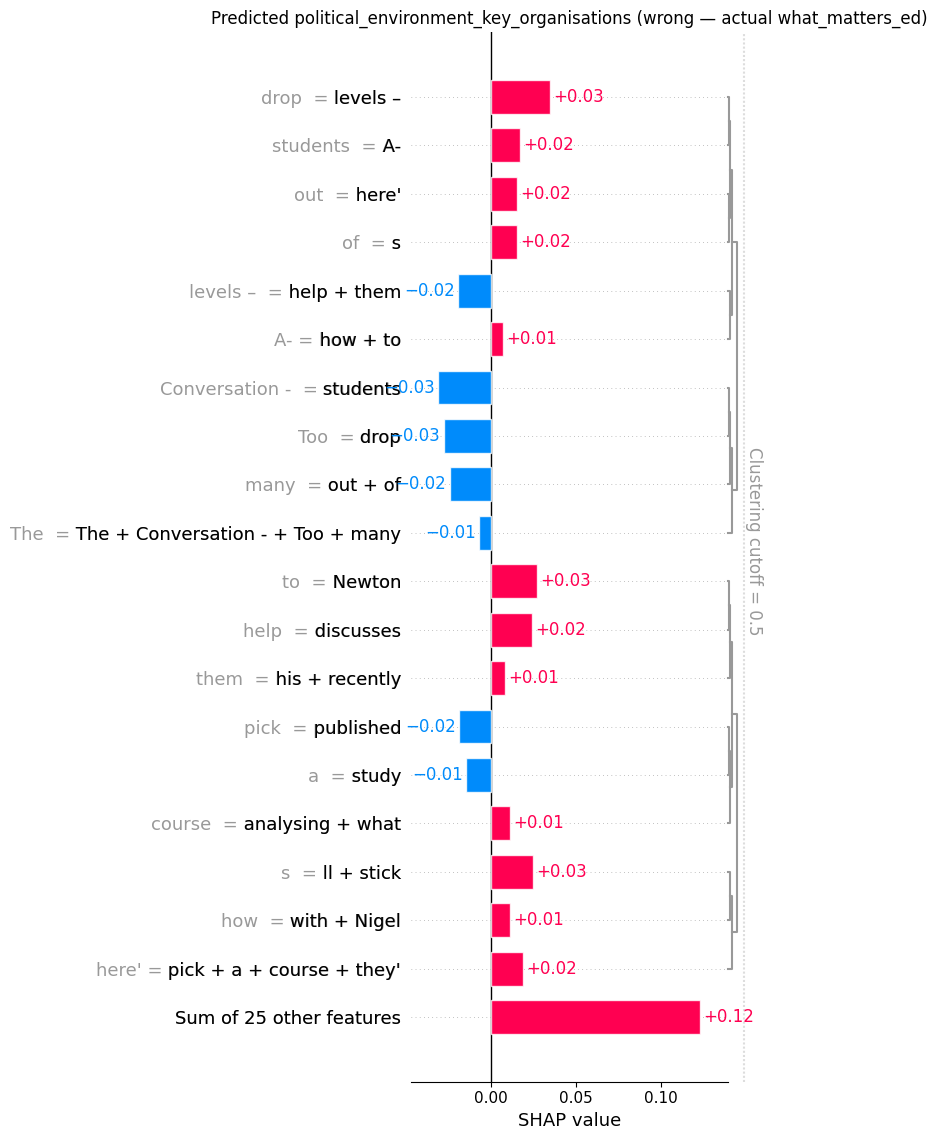


--- true=policy_practice_research, predicted=edtech (0.54) ---
Text preview: NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is likely to evolve in the next few years and whether re...


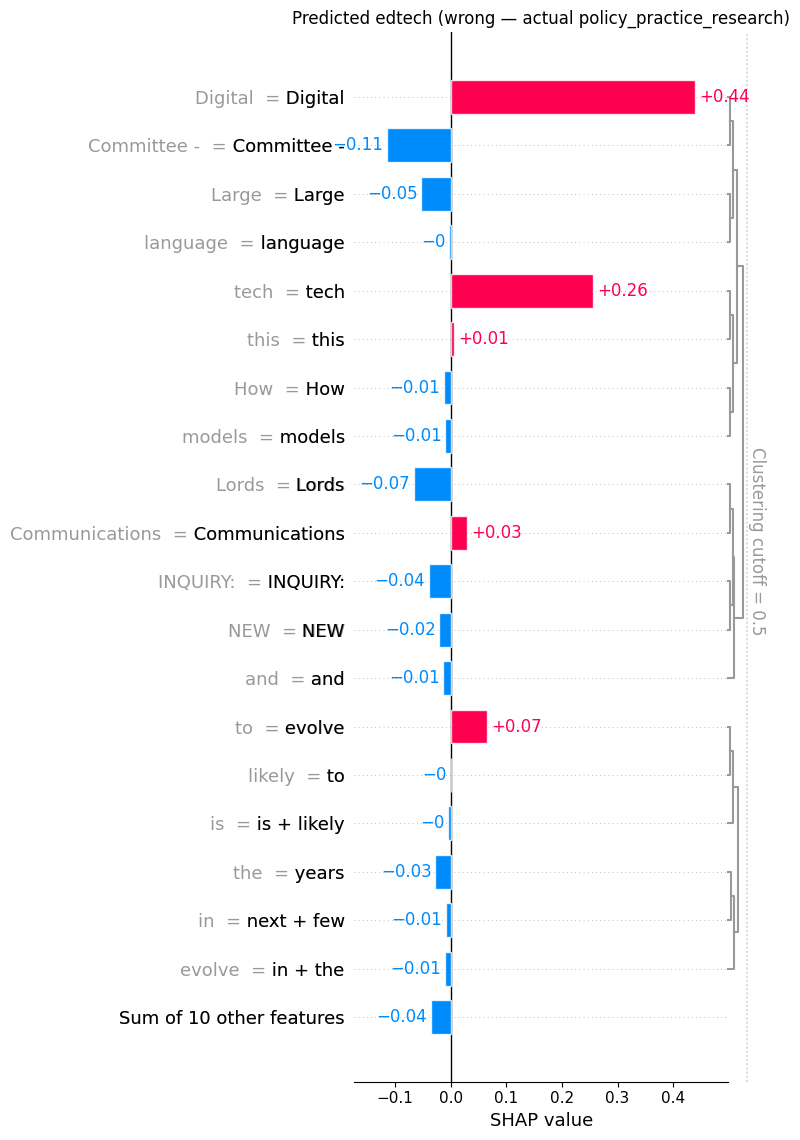


--- true=edtech, predicted=teacher_rrd (0.53) ---
Text preview: NFER - EdTech for CPD: How technology can support teacher professional development Joahnna Bohorquez Martinez, Masters student placement at NFER, and ...


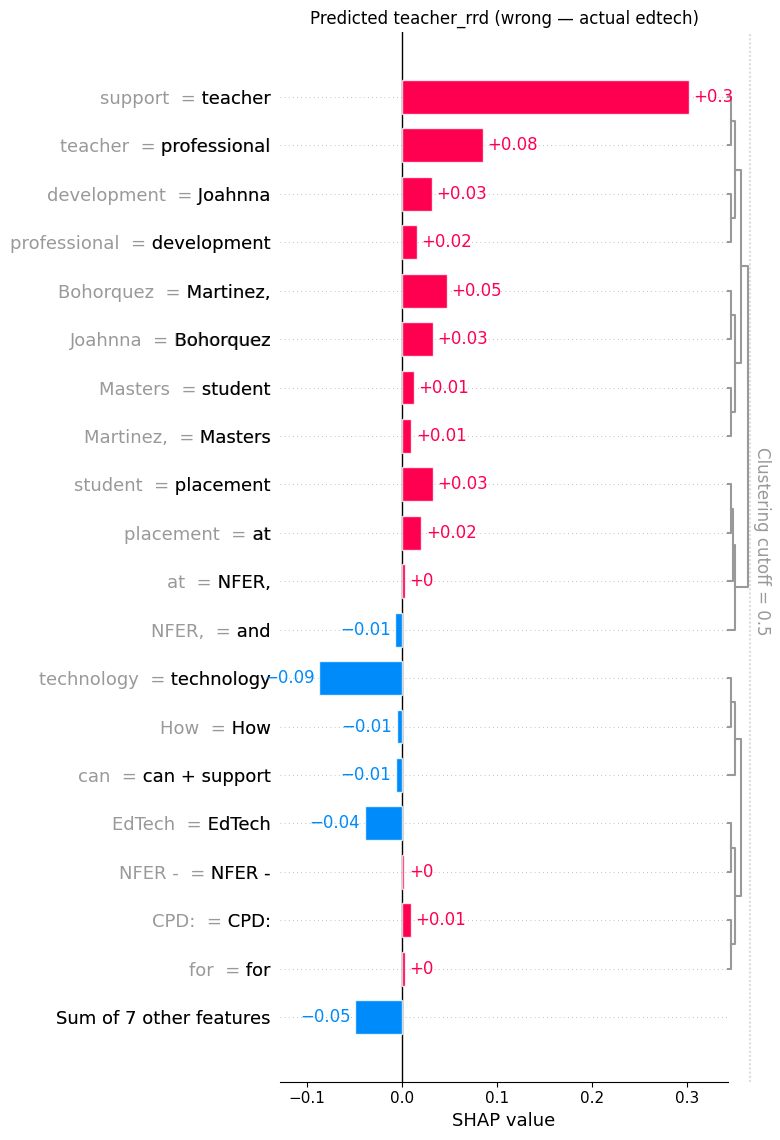

In [42]:
# One misclassified example per TRUE category
print('\n\n=== MISCLASSIFIED ARTICLES ===')
shown_cats = set()
for idx in range(len(sample_texts)):
    pred_probs = st_text_predict([sample_texts[idx]])[0]
    pred_class = label_names[np.argmax(pred_probs)]
    true_label = sample_labels[idx]
    if pred_class == true_label or true_label in shown_cats:
        continue
    shown_cats.add(true_label)
    pred_class_idx = label_names.index(pred_class)
    
    print(f'\n--- true={true_label}, predicted={pred_class} ({pred_probs[pred_class_idx]:.2f}) ---')
    print(f'Text preview: {sample_texts[idx][:150]}...')
    shap.plots.bar(shap_values_text[idx, :, pred_class_idx], max_display=20, show=False)
    plt.title(f'Predicted {pred_class} (wrong — actual {true_label})')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_plots/text_shap_wrong_{true_label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    if len(shown_cats) == 6:
        break


In [40]:
# Check: does four_nations work for all nations, not just Wales?
four_nations_idx = [i for i in range(len(sample_labels)) if sample_labels[i] == 'four_nations']
for idx in four_nations_idx:
    pred_probs = st_text_predict([sample_texts[idx]])[0]
    pred_class = label_names[np.argmax(pred_probs)]
    pred_class_idx = label_names.index('four_nations')
    conf = pred_probs[pred_class_idx]
    
    # Check which nation words appear
    text_lower = sample_texts[idx].lower()
    nations = []
    for nation in ['wales', 'welsh', 'scotland', 'scottish', 'northern ireland', 'belfast', 'stormont']:
        if nation in text_lower:
            nations.append(nation)
    
    correct = '✓' if pred_class == 'four_nations' else '✗'
    print(f'{correct} conf={conf:.2f} nations={nations or "none found"} preview={sample_texts[idx][:100]}')


✓ conf=0.56 nations=['welsh'] preview=Welsh Government - New programme of support announced for additional learning needs The new package 
✓ conf=0.79 nations=['northern ireland'] preview=DfE NI - Education Minister announces extension of the Northern Ireland Childcare Subsidy Scheme to 
✗ conf=0.07 nations=none found preview=Government devolution bill - 'Devolution Revolution' forges ahead with more powers for Mayors Raft o
✓ conf=0.74 nations=['scottish'] preview=Scottish AI - Children's Rights & AI: Teaching Pack Children's Parliament, the Scottish AI Alliance 
✓ conf=0.71 nations=['welsh'] preview=Welsh Government - Chief Executive of new Professional Learning body appointed Dr Gwenllian Lansdown
✗ conf=0.32 nations=['wales'] preview=LPIPs blog post - Putting the 'Policy' into Local Policy and Innovation Partnership: Political Engag
✓ conf=0.70 nations=['belfast'] preview=Belfast Telegraph - Education Minister 'disappointed' as teachers set to vote on further strike acti
✓ conf=0.8

### Text-level SHAP — word attribution analysis (PartitionExplainer, 167 articles)

**Correct predictions — the SHAP profile spectrum:**

| Category | Pattern | Top word (SHAP) | Confidence | What drives it |
|---|---|---|---|---|
| `four_nations` | Single keyword | "Welsh" (0.59) | 0.56 | Geographic name — fails without it |
| `edtech` | Single keyword | "AI" (0.26) | 0.89 | Tech vocabulary — captures semantic meaning TF-IDF misses |
| `teacher_rrd` | Keyword cluster | "teacher" (0.24) | 0.93 | Teacher + workforce terms ("recruitment", "retention", "bursaries") |
| `policy_practice_research` | Semi-distributed | "Research" (0.18) | 0.41 | Research vocab — low confidence reflects category overlap |
| `political_environment` | Fully distributed | max 0.02 | 0.63 | No keyword — reads accumulated political tone across 50+ words |
| `what_matters_ed` | Diffuse/competing | "parents" (0.16) | 0.45 | No distinctive vocabulary — red and blue forces nearly cancel |

Categories have fundamentally different SHAP profiles. Some are keyword-dependent (`four_nations`, `edtech`), some are context-dependent (`political_environment`), and one has no learnable signal (`what_matters_ed`). This is a labelling schema property, not a model property.

**Misclassified predictions — every one is a multi-label article:**

| True | Predicted | What happened |
|---|---|---|
| edtech | teacher_rrd | "teacher" (0.30) overwhelms "technology" (-0.09) and even "EdTech" (-0.04) |
| four_nations | policy_practice | No nation word — "devolution" pushes both ways, cancels out |
| policy_practice | edtech | "Digital" (0.44) + "tech" (0.26) overwhelms "Committee" (-0.11) + "Lords" (-0.07) |
| political_environment | what_matters_ed | "Loss" (+0.10) topic vs "Parliamentary" (-0.10) institution — topic wins |
| teacher_rrd | political_environment | "Ofsted" (0.11) institution vs teacher impact — model sees actor, human sees affected group |
| what_matters_ed | political_environment | Max word SHAP only 0.03 — any institutional vocabulary wins against no signal |

**The model isn't failing — the single-label schema is.** Every misclassification is an article that genuinely belongs in two categories. The categories describe different dimensions (who published it, what type, who it affects, what topic). This is why top-2 matters: when SHAP signals compete, the curator sees both categories and makes the editorial call.

The 0.765 F1 ceiling is partly a labelling ceiling, not a model ceiling.


# 7. Global text SHAP by category — ST without metadata (averaged across val set)

Averaged across all val articles per category, showing which words drive each category *overall* for the production model (ST without metadata). This is the text-level equivalent of the TF-IDF global bar plots from Section 3 — enabling direct specification comparison.



--- edtech (26 articles) ---


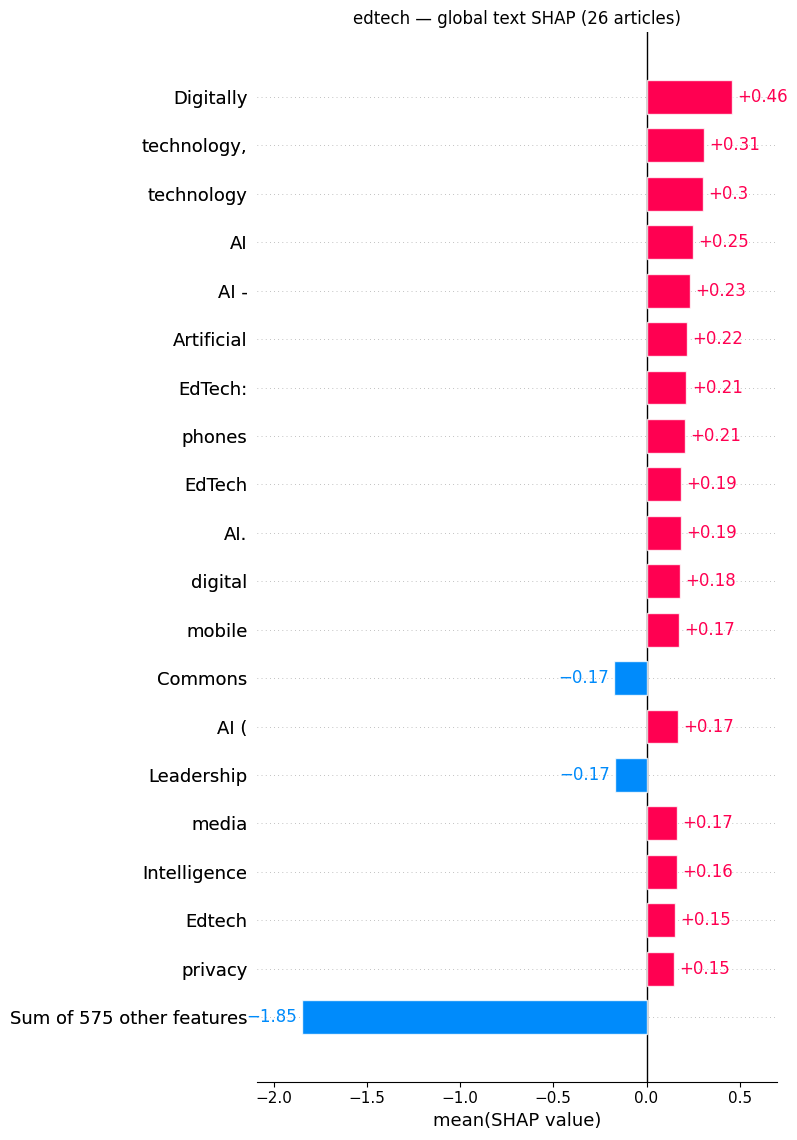


--- four_nations (22 articles) ---


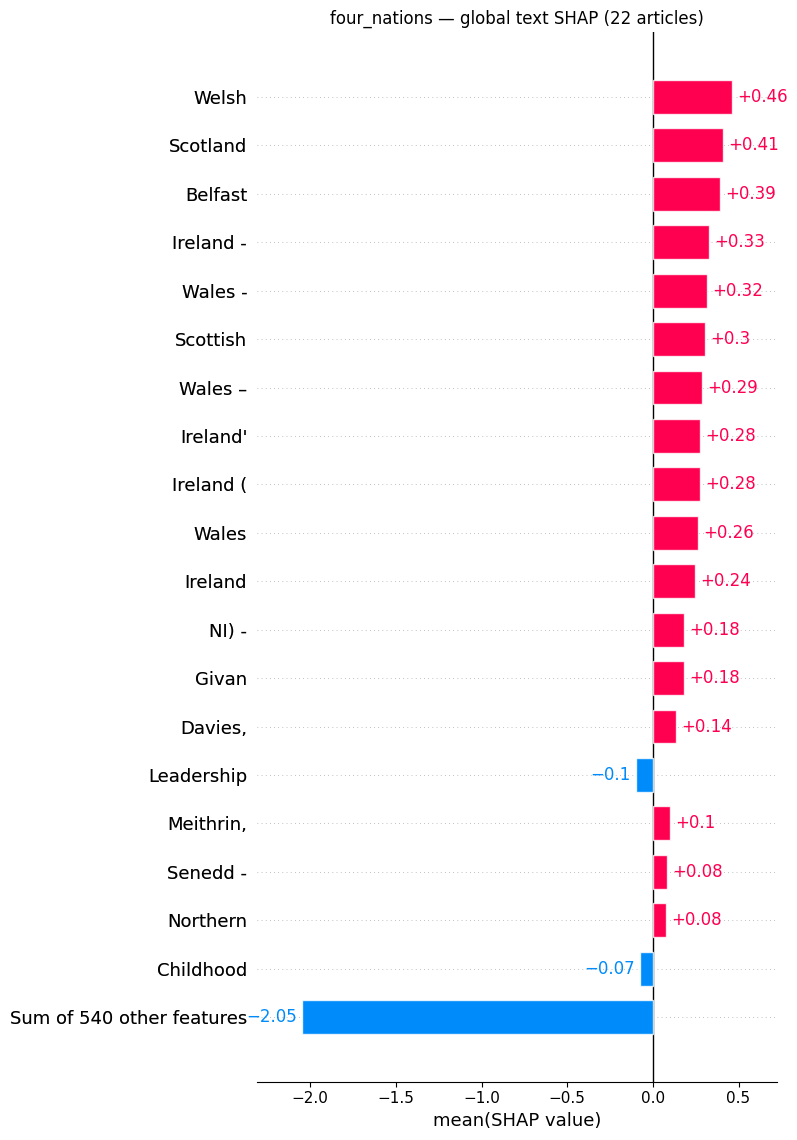


--- policy_practice_research (24 articles) ---


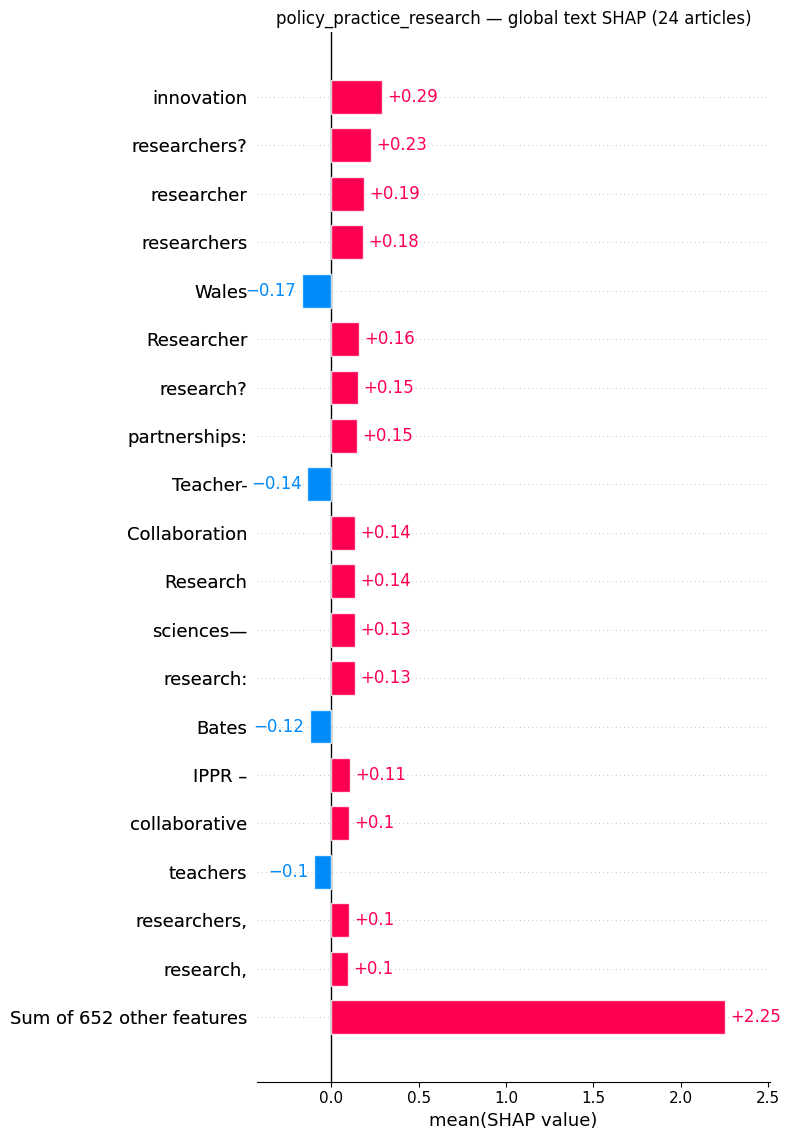


--- political_environment_key_organisations (36 articles) ---


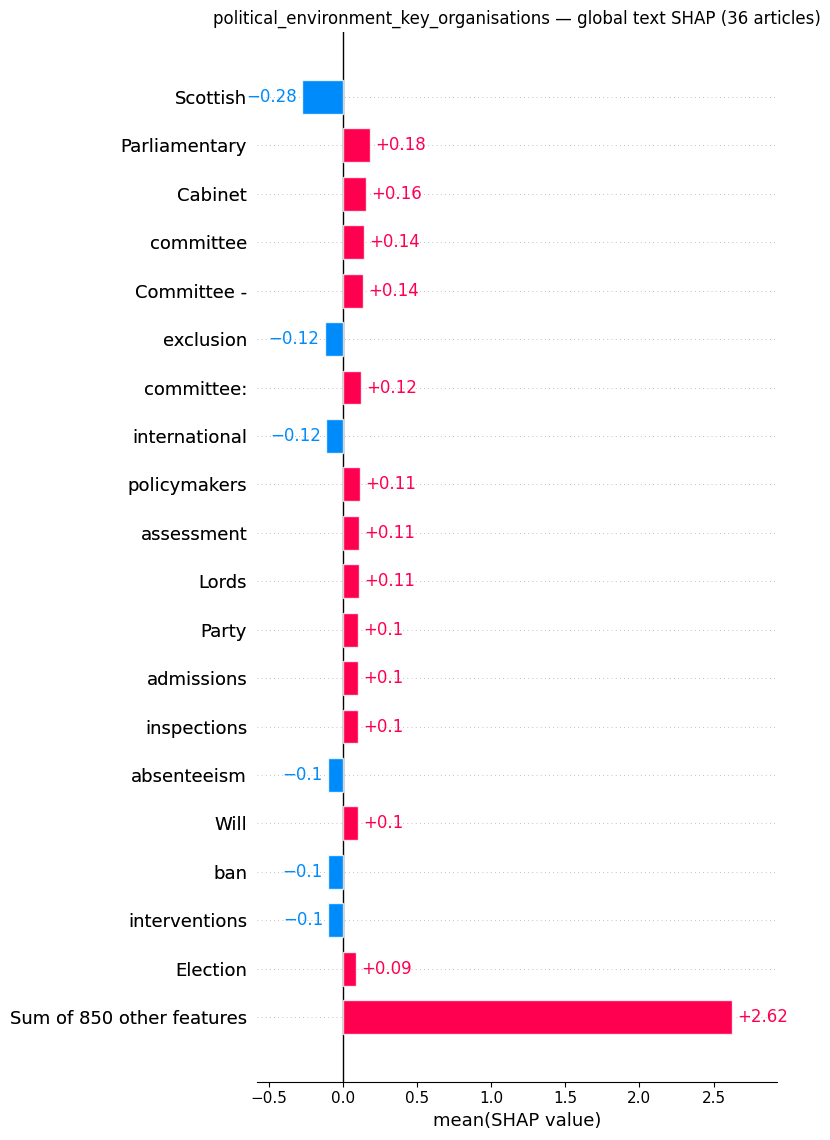


--- teacher_rrd (29 articles) ---


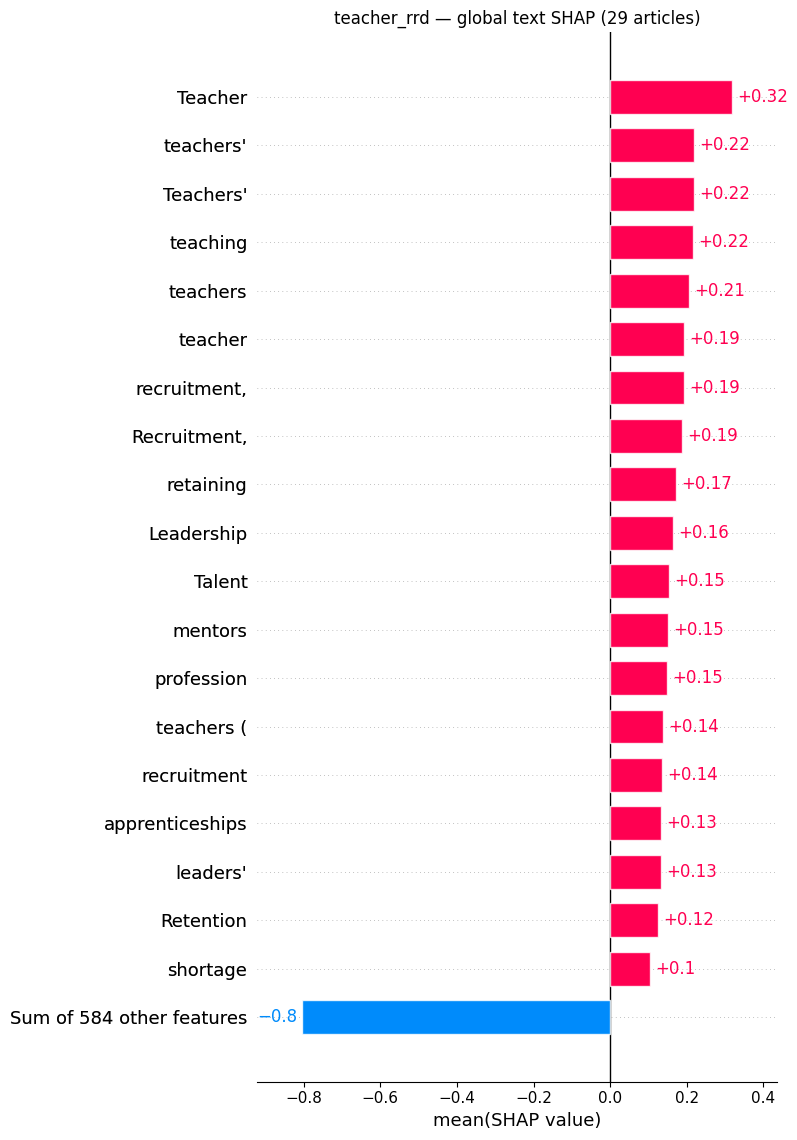


--- what_matters_ed (30 articles) ---


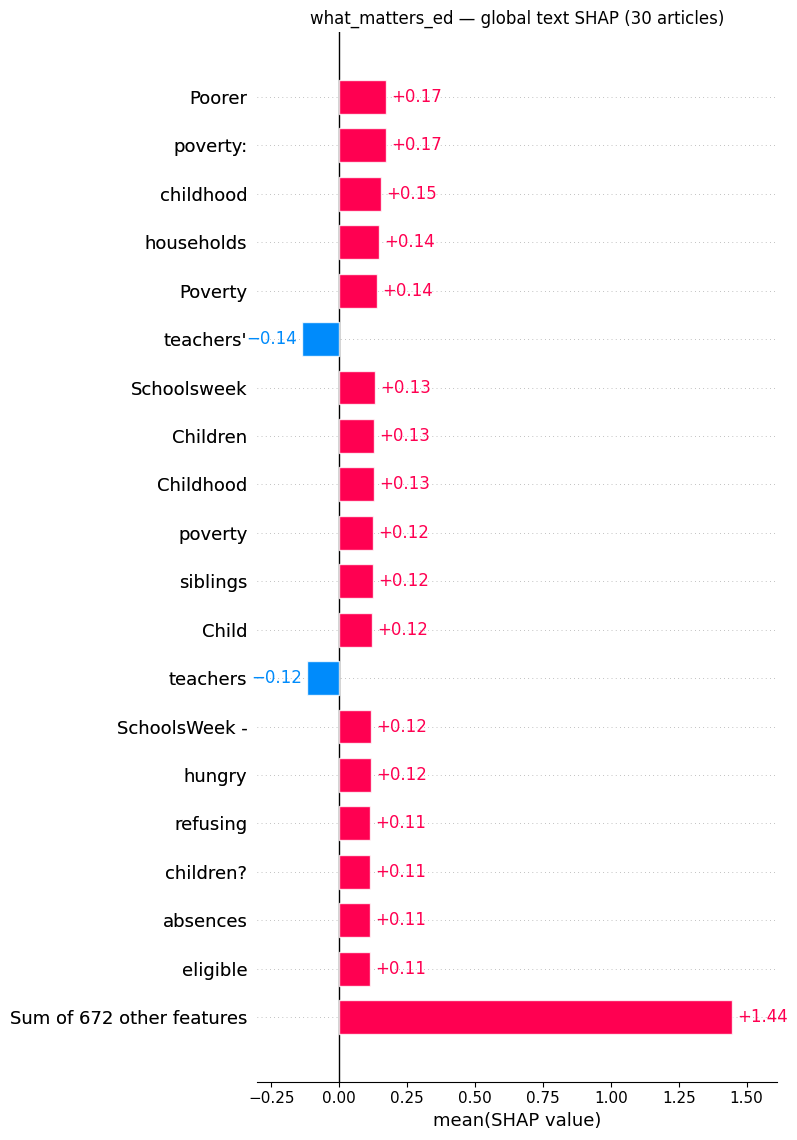

In [44]:
# Global text-level SHAP — average word importance per category
import os
os.makedirs('../outputs/shap_plots', exist_ok=True)

for i, cls in enumerate(label_names):
    cls_idx = [j for j in range(len(sample_labels)) if sample_labels[j] == cls]
    if not cls_idx:
        continue
    cls_shap = shap_values_text[cls_idx, :, i]
    
    print(f'\n--- {cls} ({len(cls_idx)} articles) ---')
    shap.plots.bar(cls_shap.mean(0), max_display=20, show=False)
    plt.title(f'{cls} — global text SHAP ({len(cls_idx)} articles)')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_plots/text_shap_global_{cls}.png', dpi=150, bbox_inches='tight')
    plt.show()


### Global text-level SHAP — which words drive each category across all articles

Averaged across all val articles per category, the text-level SHAP reveals what the model thinks each category *means*:

| Category | Articles | Top signals | Pattern |
|---|---|---|---|
| `edtech` | 26 | "Digitally" (0.46), "technology" (0.31), "AI" (0.25), "phones" (0.21), "mobile" (0.17) | Rich tech vocabulary — multiple terms contribute |
| `four_nations` | 22 | "Welsh" (0.46), "Scotland" (0.41), "Belfast" (0.39), "Ireland" (0.33), "Wales" (0.32) | All nations represented — not Wales-biased |
| `teacher_rrd` | 29 | "Teacher" (0.32), "teaching" (0.22), "recruitment" (0.19), "retaining" (0.17), "Retention" (0.12) | Strongest profile — entirely construct-valid workforce terms |
| `policy_practice_research` | 24 | "innovation" (0.29), "researchers" (0.23), "research" (0.15), "partnerships" (0.15), "Collaboration" (0.14) | Research vocabulary with "Wales" (-0.17) pushing away |
| `political_environment` | 36 | "Parliamentary" (0.18), "Cabinet" (0.16), "committee" (0.14), "policymakers" (0.11), "Lords" (0.11) | Institutional vocabulary — "Scottish" (-0.28) pushes away |
| `what_matters_ed` | 30 | "Poorer" (0.17), "poverty" (0.17), "childhood" (0.15), "households" (0.14), "hungry" (0.10) | **Surprise: coherent poverty/welfare theme** |

**Global vs individual — different stories from the same data:**
The individual article plots showed `what_matters_ed` as diffuse and unclassifiable (0.45 confidence, competing signals). The global plot reveals a clear child poverty/welfare theme — individual articles use *different poverty vocabulary* ("hungry" vs "eligible" vs "absences") but the concept is consistent. The ST captures this semantic similarity across different words, which is exactly what TF-IDF can't do.

**Specification sensitivity comparison — TF-IDF vs ST global text SHAP:**
For `political_environment` and `what_matters_ed`, TF-IDF and ST classify using **entirely different vocabulary** for the same category. TF-IDF's top feature for `what_matters_ed` was generic "children" (0.083). The ST finds "Poorer", "poverty", "households" — a specific welfare theme invisible to keyword matching. Same category, same data, different words treated as evidence. This is specification sensitivity at the most granular level.


# 8. Ablation test — ST without metadata (KernelExplainer)

What happens when we remove the 17 metadata columns from the ST + metadata model? Does performance hold, and how does the SHAP landscape change? This is the ablation that confirmed the production model choice: ST without metadata (0.750) classifies by content, not source type.

In [61]:
# ST without metadata — retrain and SHAP comparison
from sklearn.linear_model import LogisticRegression

train_df = pd.read_csv(DATA_DIR / 'train.csv')
sbert_emb_train = np.load(MODEL_DIR / 'sbert_train_embeddings.npy')

sbert_clf_no_meta = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
sbert_clf_no_meta.fit(sbert_emb_train, train_df['target'])
joblib.dump(sbert_clf_no_meta, MODEL_DIR / 'sbert_classifier_no_meta.joblib')
print('Saved no-metadata model for notebook 10.')

no_meta_pred = sbert_clf_no_meta.predict(sbert_emb_val)
no_meta_f1 = f1_score(y_val, no_meta_pred, average='macro')
print(f'ST without metadata F1: {no_meta_f1:.3f}')
print(f'ST with metadata F1: 0.765')

Saved no-metadata model for notebook 10.
ST without metadata F1: 0.750
ST with metadata F1: 0.765


In [65]:
from sklearn.utils import resample

# Bootstrap for ST + metadata
boot_meta = []
for _ in range(1000):
    idx = resample(np.arange(len(y_val)), random_state=None)
    f1 = f1_score(y_val.values[idx], sbert_pred_val[idx], average='macro')
    boot_meta.append(f1)

# Bootstrap for ST without metadata
boot_no_meta = []
for _ in range(1000):
    idx = resample(np.arange(len(y_val)), random_state=None)
    f1 = f1_score(y_val.values[idx], no_meta_pred[idx], average='macro')
    boot_no_meta.append(f1)

print(f'ST + metadata:    {np.mean(boot_meta):.3f} (95% CI: {np.percentile(boot_meta, 2.5):.3f}–{np.percentile(boot_meta, 97.5):.3f})')
print(f'ST without meta:  {np.mean(boot_no_meta):.3f} (95% CI: {np.percentile(boot_no_meta, 2.5):.3f}–{np.percentile(boot_no_meta, 97.5):.3f})')

# Do the CIs overlap?
overlap = np.percentile(boot_no_meta, 97.5) >= np.percentile(boot_meta, 2.5)
print(f'\nCIs overlap: {overlap}')
if overlap:
    print('The difference is NOT statistically significant — further justifies choosing the cleaner model.')

ST + metadata:    0.761 (95% CI: 0.696–0.823)
ST without meta:  0.747 (95% CI: 0.678–0.812)

CIs overlap: True
The difference is NOT statistically significant — further justifies choosing the cleaner model.


### Bootstrap confidence intervals (1000 resamples)

| Model | Macro F1 | 95% CI |
|---|---|---|
| ST + metadata | 0.761 | 0.696 – 0.823 |
| ST without metadata | 0.747 | 0.678 – 0.812 |

**The confidence intervals overlap substantially.** The +1.5 F1 difference between the two models is not statistically significant on 167 val articles. This means the accuracy cost of removing metadata is indistinguishable from sampling noise — while the SHAP landscape change (from metadata-dominated to content-driven) is real and measurable.

This is the final justification for the model switch: you give up nothing statistically, but gain a model that classifies by content rather than source type.


In [64]:
# SHAP on embeddings only
background_no_meta = shap.kmeans(sbert_emb_val, 10)
explainer_no_meta = shap.KernelExplainer(sbert_clf_no_meta.predict_proba, background_no_meta)
shap_values_no_meta = explainer_no_meta.shap_values(sbert_emb_val, nsamples=200)

# Top features per class — should be all embedding dimensions now
feature_names_emb = [f'emb_{i}' for i in range(384)]
for i, cls in enumerate(label_names):
    mean_shap = np.abs(shap_values_no_meta[:, :, i]).mean(axis=0)
    top_idx = np.argsort(mean_shap)[-5:][::-1]
    print(f'\n--- {cls} ---')
    for j in top_idx:
        print(f'  {mean_shap[j]:.4f}  {feature_names_emb[j]}')

  0%|          | 0/167 [00:00<?, ?it/s]


--- edtech ---
  0.0047  emb_291
  0.0038  emb_367
  0.0022  emb_123
  0.0022  emb_290
  0.0020  emb_179

--- four_nations ---
  0.0026  emb_333
  0.0025  emb_121
  0.0023  emb_292
  0.0021  emb_192
  0.0019  emb_40

--- policy_practice_research ---
  0.0026  emb_53
  0.0021  emb_207
  0.0019  emb_165
  0.0018  emb_136
  0.0018  emb_324

--- political_environment_key_organisations ---
  0.0026  emb_296
  0.0020  emb_191
  0.0017  emb_97
  0.0017  emb_77
  0.0015  emb_218

--- teacher_rrd ---
  0.0055  emb_97
  0.0046  emb_118
  0.0033  emb_236
  0.0028  emb_347
  0.0024  emb_231

--- what_matters_ed ---
  0.0040  emb_117
  0.0036  emb_189
  0.0029  emb_329
  0.0024  emb_108
  0.0020  emb_0


### ST SHAP without metadata — specification sensitivity at the feature level

Removing metadata completely changes the SHAP landscape:

| | With metadata | Without metadata |
|---|---|---|
| Highest SHAP value | 0.038 (org_government_public_sector) | 0.007 (emb_97) |
| Feature type in top 10 | 4-10/10 metadata across categories | 100% embedding dimensions |
| Importance distribution | Concentrated on few metadata columns | Distributed across many dimensions |
| `policy_practice_research` signal | Strong (10/10 metadata) | Weakest of all categories (0.0019) |

**But accuracy barely changes:** 0.765 → 0.750 (−1.5 points). Metadata-only scores 0.316 (near random). The embeddings carry the real classification power — metadata is a convenient shortcut that LogReg prefers, not the source of predictive ability.

**Specification sensitivity finding:** one binary choice (include 17 metadata columns or not) produces a near-total SHAP feature set replacement while barely changing accuracy. This is specification sensitivity that accuracy alone cannot detect — you need SHAP to see it.


# 9. Ablation test — metadata-only baseline (LogReg)

Can metadata alone classify articles? If metadata-only scores high, the ST genuinely depends on metadata. If it scores low, the SHAP metadata dominance is just LogReg preferring clean binary columns — not actual dependency.

In [18]:
from sklearn.linear_model import LogisticRegression
train_df = pd.read_csv(DATA_DIR / 'train.csv')
X_meta_only_train = train_df[metadata_cols].values
X_meta_only_val = val_df[metadata_cols].values
meta_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
meta_clf.fit(X_meta_only_train, train_df['target'])
meta_f1 = f1_score(y_val, meta_clf.predict(X_meta_only_val), average='macro')
print(f'Metadata-only F1: {meta_f1:.3f}')
print(f'ST + metadata F1: 0.765')
print(f'ST without metadata F1: 0.750')


Metadata-only F1: 0.316
ST + metadata F1: 0.765
ST without metadata F1: 0.750


### Metadata dependency test
Metadata alone is barely above random (1/6 = 0.167). The embeddings do the real work — 0.750 without any metadata. Adding metadata gives +1.5 points, but the SHAP analysis above shows that LogReg *prefers* those 17 clean binary columns over 384 continuous embedding dimensions. The classifier takes the path of least resistance, not the path of most information.

**This means the metadata dependency in the SHAP results is a classifier behaviour, not a model dependency.** The ST doesn't *need* metadata — LogReg just *likes* it. A different classifier head (or removing metadata entirely) would shift the SHAP landscape completely while barely changing accuracy. That's a specification choice, not a performance choice.


# 10. Ablation test — XGBoost alternative model (embeddings + metadata)

Does a non-linear classifier use embeddings + metadata differently than LogReg? Tests whether the metadata dependency is a LogReg behaviour or a general pattern.

In [25]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(train_df['target'])
y_val_enc = le.transform(y_val)

# Load train embeddings
sbert_emb_train = np.load(MODEL_DIR / 'sbert_train_embeddings.npy')
X_train_xgb = np.hstack([sbert_emb_train, train_df[metadata_cols].values])

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train_xgb, y_train_enc)
xgb_pred = le.inverse_transform(xgb_clf.predict(X_val_sbert))
xgb_f1 = f1_score(y_val, xgb_pred, average='macro')
print(f'XGBoost + embeddings + metadata F1: {xgb_f1:.3f}')
print(f'ST LogReg + metadata F1: 0.765')


XGBoost + embeddings + metadata F1: 0.700
ST LogReg + metadata F1: 0.765


### Alternative model test — XGBoost

| Model | Features | Macro F1 |
|---|---|---|
| ST + LogReg | embeddings + metadata | **0.765** |
| XGBoost | embeddings + metadata | **0.700** |

Same features, different model — XGBoost scores 6.5 points lower. With 942 training rows and 401 features, XGBoost overfits: enough capacity to memorise the training set, not enough data to generalise. LogReg's constraint (linear decision boundaries only) acts as regularisation, preventing overfitting on a small dataset.

For the SST argument: this is another specification choice producing a different result. Same data, same features, different model architecture → different F1. The specification (which model) matters.


# 11. Individual prediction explanations — ST without metadata (production model)

Waterfall plots for specific interesting cases: high-confidence wrong predictions and low-confidence correct predictions. Uses the no-metadata model and SHAP values — these show embedding dimensions (not human-readable) but demonstrate where the production model is confident and wrong vs uncertain and right. For word-level explanations, see the text-level SHAP bar plots in Section 6.

In [45]:
# Find interesting cases — using ST without metadata (production model)
no_meta_preds = sbert_clf_no_meta.predict(sbert_emb_val)
no_meta_proba = sbert_clf_no_meta.predict_proba(sbert_emb_val)
sample_preds = no_meta_preds[sample_idx]
sample_true = y_val.values[sample_idx]
sample_conf = no_meta_proba[sample_idx].max(axis=1)

# Case 1: High-confidence wrong prediction
wrong_mask = sample_preds != sample_true
if wrong_mask.any():
    wrong_confs = sample_conf.copy()
    wrong_confs[~wrong_mask] = 0
    case1_idx = np.argmax(wrong_confs)
    print(f'Case 1 — High-confidence wrong prediction:')
    print(f'  True: {sample_true[case1_idx]}, Predicted: {sample_preds[case1_idx]} ({sample_conf[case1_idx]:.2f})')
    print(f'  Text: {val_df.iloc[sample_idx[case1_idx]]["text_clean"][:150]}')

# Case 2: Low-confidence correct prediction
correct_mask = sample_preds == sample_true
if correct_mask.any():
    correct_confs = sample_conf.copy()
    correct_confs[~correct_mask] = 1
    case2_idx = np.argmin(correct_confs)
    print(f'\nCase 2 — Low-confidence correct prediction:')
    print(f'  True: {sample_true[case2_idx]}, Predicted: {sample_preds[case2_idx]} ({sample_conf[case2_idx]:.2f})')
    print(f'  Text: {val_df.iloc[sample_idx[case2_idx]]["text_clean"][:150]}')

Case 1 — High-confidence wrong prediction:
  True: political_environment_key_organisations, Predicted: teacher_rrd (0.81)
  Text: Reject fewer teacher applicants, DfE tells trainers Susan Acland-Hood, the DfE's permanent secretary, told providers a 7 per cent jump in applicants t

Case 2 — Low-confidence correct prediction:
  True: political_environment_key_organisations, Predicted: political_environment_key_organisations (0.30)
  Text: APPG for Education report– Inquiry into 'The Loss of the Love of Learning' The All-Party Parliamentary Group for Education report highlights "a number


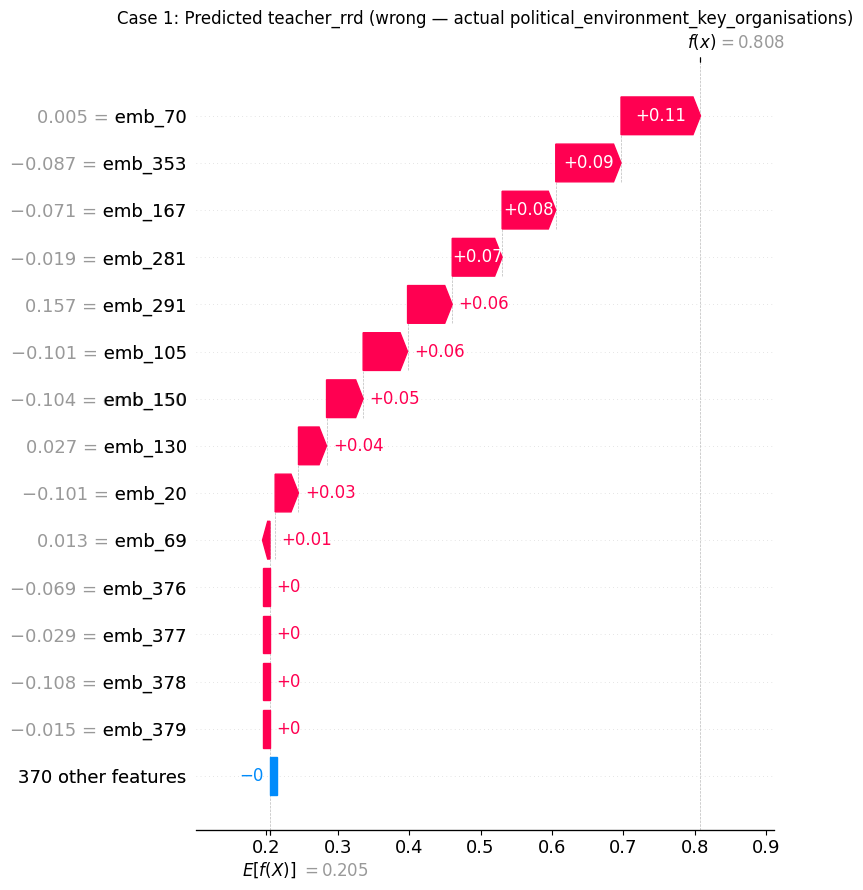

In [46]:
# Waterfall plot for Case 1: high-confidence wrong prediction
if wrong_mask.any():
    pred_class_idx = np.where(np.array(label_names) == sample_preds[case1_idx])[0][0]
    
    explanation = shap.Explanation(
        values=shap_values_no_meta[case1_idx, :, pred_class_idx],
        base_values=explainer_no_meta.expected_value[pred_class_idx],
        data=sbert_emb_val[sample_idx[case1_idx]],
        feature_names=feature_names_emb,
    )
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f'Case 1: Predicted {sample_preds[case1_idx]} (wrong — actual {sample_true[case1_idx]})')
    plt.tight_layout()
    plt.show()

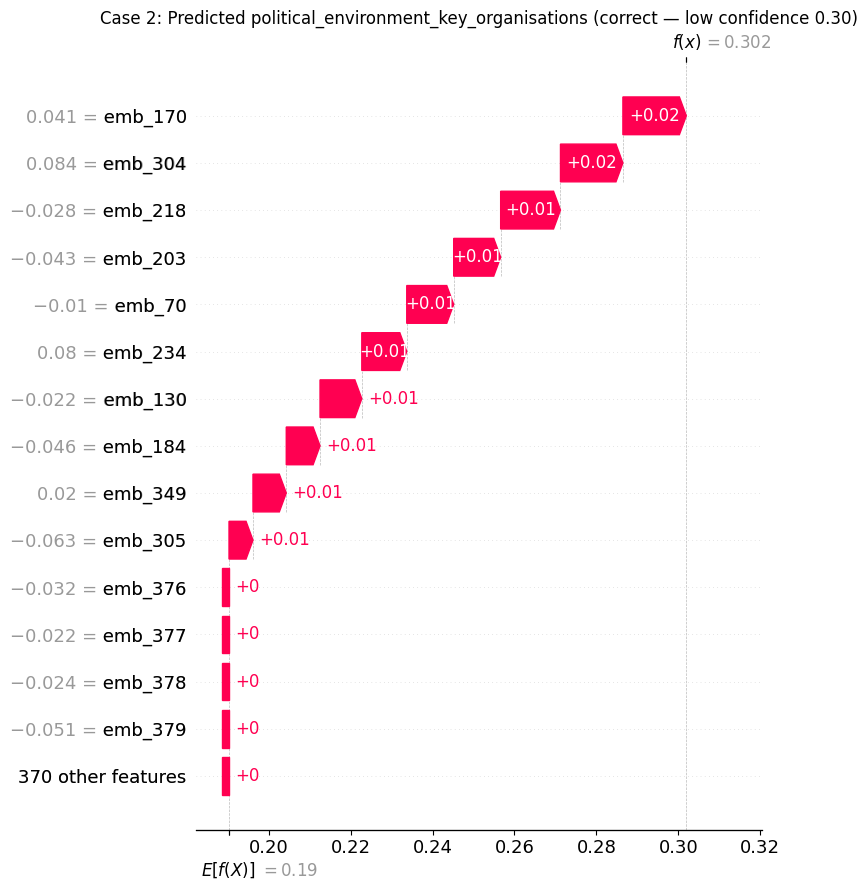

In [47]:
# Waterfall plot for Case 2: low-confidence correct prediction
if correct_mask.any():
    pred_class_idx = np.where(np.array(label_names) == sample_preds[case2_idx])[0][0]
    
    explanation = shap.Explanation(
        values=shap_values_no_meta[case2_idx, :, pred_class_idx],
        base_values=explainer_no_meta.expected_value[pred_class_idx],
        data=sbert_emb_val[sample_idx[case2_idx]],
        feature_names=feature_names_emb,
    )
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f'Case 2: Predicted {sample_preds[case2_idx]} (correct — low confidence {sample_conf[case2_idx]:.2f})')
    plt.tight_layout()
    plt.show()


### Waterfall plot interpretation

The waterfall plots show embedding dimensions (emb_70, emb_353 etc.) which are not human-readable — "emb_70" doesn't map to a specific word. They confirm that the no-metadata model distributes importance across many dimensions (Case 2) or concentrates on a few (Case 1), but for human-readable word-level explanations, see the text-level SHAP bar plots in Section 6.

# 12. Normative divergence — Claude API (zero-shot) vs ST without metadata (production model)

For articles where Claude and the Sentence Transformer disagree, what features drove the ST's prediction? Shows the mechanism behind normative divergence — Claude classifies by document type (encoded in prompt descriptions), the ST classifies by topic content (learned from embeddings). Different specifications encoding different assumptions about what each category means.

In [53]:
# Load Claude zero-shot predictions for comparison
claude_zero_df = pd.read_csv(DATA_DIR / 'claude_zero_shot_predictions.csv')

# Keep only rows where Claude predicted a valid category
valid_mask = claude_zero_df['category'].isin(label_names)
valid_idx = np.where(valid_mask)[0]

claude_preds = claude_zero_df.loc[valid_mask, 'category'].values
st_preds_aligned = no_meta_preds[valid_idx]
true_aligned = y_val.values[valid_idx]
conf_aligned = no_meta_proba[valid_idx].max(axis=1)

disagree = np.where(claude_preds != st_preds_aligned)[0]
print(f'Matched articles: {len(valid_idx)}/167 (1 excluded — Claude predicted invalid category)')
print(f'Disagreements: {len(disagree)}/{len(valid_idx)}')

for case_num, idx in enumerate(disagree[:3]):
    orig_idx = valid_idx[idx]
    print(f'\n--- Disagreement {case_num + 1} ---')
    print(f'  True: {true_aligned[idx]}')
    print(f'  ST predicted: {st_preds_aligned[idx]} ({conf_aligned[idx]:.2f})')
    print(f'  Claude predicted: {claude_preds[idx]}')
    print(f'  Text: {val_df.iloc[orig_idx]["text_clean"][:150]}')
    
    pred_class_idx = np.where(np.array(label_names) == st_preds_aligned[idx])[0][0]
    shap_vals = shap_values_no_meta[orig_idx, :, pred_class_idx]
    top_features = np.argsort(np.abs(shap_vals))[-5:][::-1]
    print(f'  ST driven by:')
    for j in top_features:
        print(f'    {shap_vals[j]:+.4f}  {feature_names_emb[j]}')


Matched articles: 166/167 (1 excluded — Claude predicted invalid category)
Disagreements: 43/166

--- Disagreement 1 ---
  True: what_matters_ed
  ST predicted: what_matters_ed (0.46)
  Claude predicted: policy_practice_research
  Text: The Conversation - Home education: why are so many parents choosing it over mainstream school? Lucie Wheeler, Education Research Assistant and PhD Can
  ST driven by:
    +0.0455  emb_381
    +0.0416  emb_108
    +0.0406  emb_0
    +0.0334  emb_158
    +0.0329  emb_236

--- Disagreement 2 ---
  True: what_matters_ed
  ST predicted: what_matters_ed (0.57)
  Claude predicted: policy_practice_research
  Text: Sutton Trust research brief - Double Disadvantage? Socio-economic inequalities in the SEND system Charlotte O'Regan and Kevin Latham Children eligible
  ST driven by:
    +0.0646  emb_292
    +0.0542  emb_297
    +0.0440  emb_26
    +0.0379  emb_329
    +0.0365  emb_243

--- Disagreement 3 ---
  True: teacher_rrd
  ST predicted: what_matters_ed (0.24)

In [54]:
# On the 43 disagreement articles — who's right?
st_correct_on_disagree = (st_preds_aligned[disagree] == true_aligned[disagree]).sum()
claude_correct_on_disagree = (claude_preds[disagree] == true_aligned[disagree]).sum()
both_wrong = ((st_preds_aligned[disagree] != true_aligned[disagree]) & 
              (claude_preds[disagree] != true_aligned[disagree])).sum()

print(f'On 43 disagreement articles:')
print(f'  ST correct: {st_correct_on_disagree}')
print(f'  Claude correct: {claude_correct_on_disagree}')
print(f'  Both wrong: {both_wrong}')

On 43 disagreement articles:
  ST correct: 24
  Claude correct: 11
  Both wrong: 8


### Normative divergence — ST vs Claude

43/166 articles (26%) — Claude and the ST (without metadata) disagree on roughly a quarter of the val set.

The dominant pattern: Claude over-predicts `policy_practice_research` because its category description emphasises "research reports, academic studies." Any article mentioning research gets pulled there. The ST classifies by topic content — welfare/disadvantage articles go to `what_matters_ed`, teacher articles go to `teacher_rrd`, regardless of whether they're formatted as research.

This is normative divergence: two specifications encoding different assumptions about what each category means. Claude classifies by **document type** (is this a research output?). The ST classifies by **topic** (what is this about?). Neither is wrong — they're answering different questions. The curator decides which matters for the newsletter.

### Who's right when they disagree?

| | Count | % of 43 disagreements |
|---|---|---|
| ST correct, Claude wrong | 24 | 56% |
| Claude correct, ST wrong | 11 | 26% |
| Both wrong | 8 | 19% |

The ST wins the disagreement zone 2:1. When they disagree, the ST is right more than twice as often as Claude.

Claude's higher top-2 (93.4% vs 91.6%) comes from the agreement zone — the easy articles. On the hard articles where specifications diverge, the ST is substantially better. This is because the ST classifies by topic content while Claude classifies by document type — and the human labels are topic-based, so the ST's specification aligns better with the ground truth.

**SST finding:** two models with similar accuracy (0.750 vs 0.717) have completely different error profiles. They get *different articles* wrong. Accuracy is an aggregate that masks which specification choices matter for which articles. A SpecCheck disagreement analysis would surface this — flagging not just the overall rate but who's right, and why.



# Summary & Conclusions

**Original model:** ST + metadata (0.765 macro F1, 91.6% top-2)

**Final model after SHAP audit:** ST without metadata (0.750 macro F1)

**Why the change:** SHAP revealed the metadata model classifies by source type (who published it) rather than content (what it's about) for 4/6 categories. Proxy concentration averaged 27.6% across all categories, with two categories above 40%. Metadata-only scores 0.316 — confirming the embeddings carry the real classification power and metadata is a convenient shortcut the classifier prefers, not a genuine dependency.

**Key SHAP findings:**
1. Each specification uses different evidence — TF-IDF uses keywords, ST uses metadata shortcuts or semantic content, Claude uses prompt descriptions
2. Categories have fundamentally different SHAP profiles — from single-keyword (`four_nations`) to fully distributed (`political_environment`) to catch-all (`what_matters_ed`)
3. Every misclassification is a multi-label article forced into a single label — the 0.765 ceiling is partly a labelling ceiling
4. Global text SHAP reveals `what_matters_ed` has a coherent poverty/welfare theme — invisible at the individual article level, visible when averaged
5. ST wins the normative divergence zone 2:1 over Claude (24 vs 11 on 43 disagreement articles)
6. Adding metadata barely changes accuracy (+1.5 points) but completely changes the SHAP landscape — specification sensitivity that accuracy alone cannot detect

**Next:** Notebook 10 — Production pipeline with ST without metadata, inference, and monitoring.
